In [1]:
import wfdb
import matplotlib.pyplot as plt

print("WFDB and Matplotlib are working!")

WFDB and Matplotlib are working!


In [2]:
record = wfdb.rdrecord(
    'a01',
    pn_dir='apnea-ecg'
)

print("Record loaded successfully!")
print("Number of samples:", len(record.p_signal))
print("Sampling frequency:", record.fs)
print("Signal shape:", record.p_signal.shape)

Record loaded successfully!
Number of samples: 2957000
Sampling frequency: 100
Signal shape: (2957000, 1)


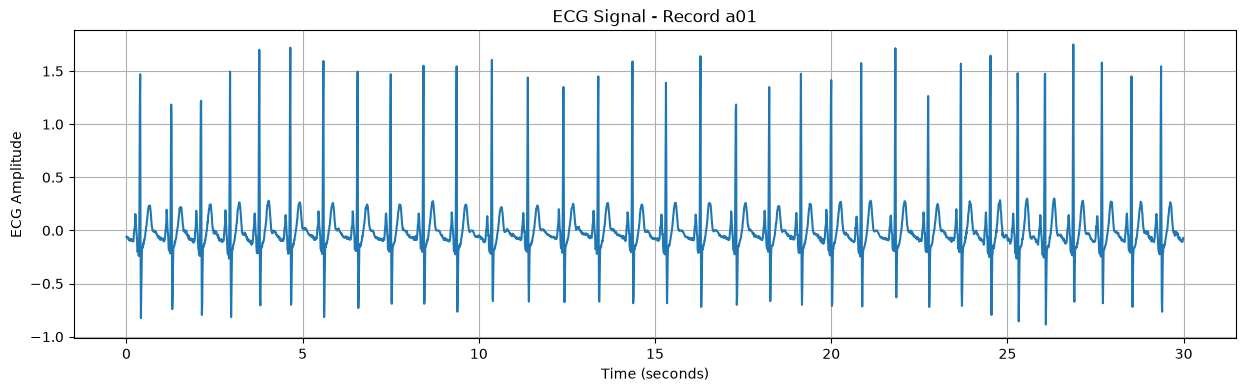

In [3]:
import numpy as np

ecg = record.p_signal[:, 0]

time = np.arange(len(ecg)) / record.fs

plt.figure(figsize=(15, 4))
plt.plot(time[:3000], ecg[:3000])

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("ECG Signal - Record a01")
plt.grid()

plt.show()

In [4]:
# Load apnea annotations
annotation = wfdb.rdann(
    'a01',
    'apn',
    pn_dir='apnea-ecg'
)

print("Annotations loaded successfully!")
print("Number of annotations:", len(annotation.sample))
print("First 20 annotation symbols:")
print(annotation.symbol[:20])

Annotations loaded successfully!
Number of annotations: 489
First 20 annotation symbols:
['N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'N', 'A', 'A', 'A', 'A', 'A', 'A', 'A']


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Count annotation types
unique, counts = np.unique(annotation.symbol, return_counts=True)

print("Annotation types:")
for symbol, count in zip(unique, counts):
    print(symbol, ":", count)

Annotation types:
A : 470
N : 19


In [6]:
# Get annotation times in seconds
annotation_times = annotation.sample / record.fs

# Separate apnea and normal annotations
apnea_times = annotation_times[np.array(annotation.symbol) == 'A']
normal_times = annotation_times[np.array(annotation.symbol) == 'N']

print("Apnea annotations:", len(apnea_times))
print("Normal annotations:", len(normal_times))

print("\nFirst 10 apnea times:")
print(apnea_times[:10])

print("\nFirst 10 normal times:")
print(normal_times[:10])


Apnea annotations: 470
Normal annotations: 19

First 10 apnea times:
[ 780.  840.  900.  960. 1020. 1080. 1140. 1200. 1260. 1320.]

First 10 normal times:
[  0.  60. 120. 180. 240. 300. 360. 420. 480. 540.]


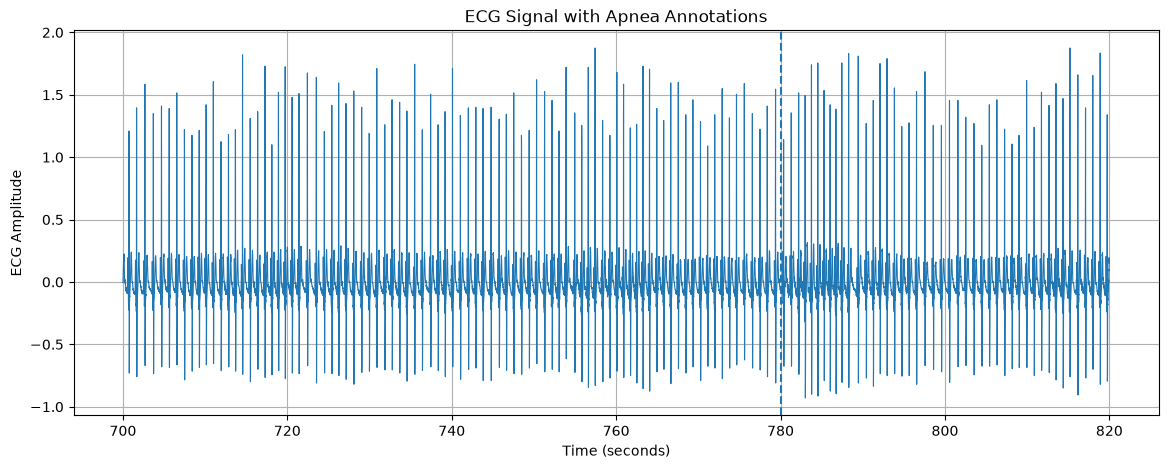

In [7]:
# Plot a 2-minute section of the ECG
start_time = 700
end_time = 820

start_sample = int(start_time * record.fs)
end_sample = int(end_time * record.fs)

ecg_segment = record.p_signal[start_sample:end_sample, 0]
time = np.arange(start_sample, end_sample) / record.fs

plt.figure(figsize=(14, 5))

plt.plot(time, ecg_segment, linewidth=0.8)

# Mark apnea annotations in this time range
for t in apnea_times:
    if start_time <= t <= end_time:
        plt.axvline(t, linestyle='--', label='Apnea')

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("ECG Signal with Apnea Annotations")
plt.grid()

plt.show()

In [8]:
print("Record duration:", len(record.p_signal) / record.fs, "seconds")
print("Sampling frequency:", record.fs, "Hz")
print("Number of apnea annotations:", len(apnea_times))
print("Number of normal annotations:", len(normal_times))

Record duration: 29570.0 seconds
Sampling frequency: 100 Hz
Number of apnea annotations: 470
Number of normal annotations: 19


In [9]:
first_apnea = apnea_times[0]

print("First apnea sample:", first_apnea)
print("First apnea time:", first_apnea / record.fs, "seconds")

First apnea sample: 780.0
First apnea time: 7.8 seconds


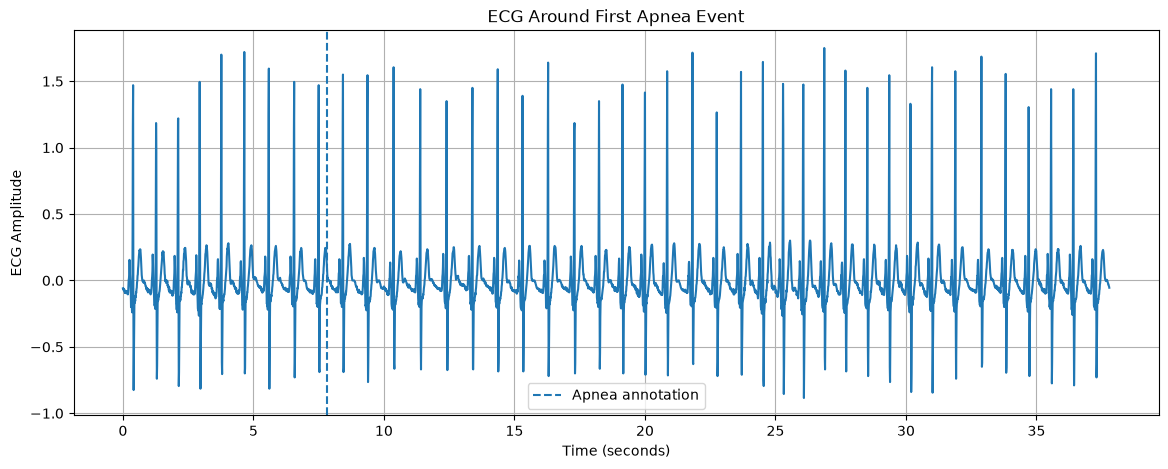

In [10]:
# Plot 60 seconds of ECG around the first apnea event

fs = record.fs

start_sample = int(first_apnea - 30 * fs)
end_sample = int(first_apnea + 30 * fs)

# Make sure we don't go outside the recording
start_sample = max(0, start_sample)
end_sample = min(len(record.p_signal), end_sample)

ecg_segment = record.p_signal[start_sample:end_sample, 0]

time = np.arange(start_sample, end_sample) / fs

plt.figure(figsize=(14, 5))
plt.plot(time, ecg_segment)

plt.axvline(
    first_apnea / fs,
    linestyle='--',
    label='Apnea annotation'
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("ECG Around First Apnea Event")
plt.legend()
plt.grid()

plt.show()

In [11]:
# Inspect the first 20 apnea annotation times

print("First 20 apnea events:")
for i, sample in enumerate(apnea_times[:20]):
    print(
        f"Event {i+1}: "
        f"sample = {sample:.0f}, "
        f"time = {sample / record.fs:.2f} seconds"
    )

First 20 apnea events:
Event 1: sample = 780, time = 7.80 seconds
Event 2: sample = 840, time = 8.40 seconds
Event 3: sample = 900, time = 9.00 seconds
Event 4: sample = 960, time = 9.60 seconds
Event 5: sample = 1020, time = 10.20 seconds
Event 6: sample = 1080, time = 10.80 seconds
Event 7: sample = 1140, time = 11.40 seconds
Event 8: sample = 1200, time = 12.00 seconds
Event 9: sample = 1260, time = 12.60 seconds
Event 10: sample = 1320, time = 13.20 seconds
Event 11: sample = 1380, time = 13.80 seconds
Event 12: sample = 1440, time = 14.40 seconds
Event 13: sample = 1500, time = 15.00 seconds
Event 14: sample = 1560, time = 15.60 seconds
Event 15: sample = 1620, time = 16.20 seconds
Event 16: sample = 1680, time = 16.80 seconds
Event 17: sample = 1740, time = 17.40 seconds
Event 18: sample = 1800, time = 18.00 seconds
Event 19: sample = 1860, time = 18.60 seconds
Event 20: sample = 1920, time = 19.20 seconds


In [12]:
print(record.p_signal.shape)

(2957000, 1)


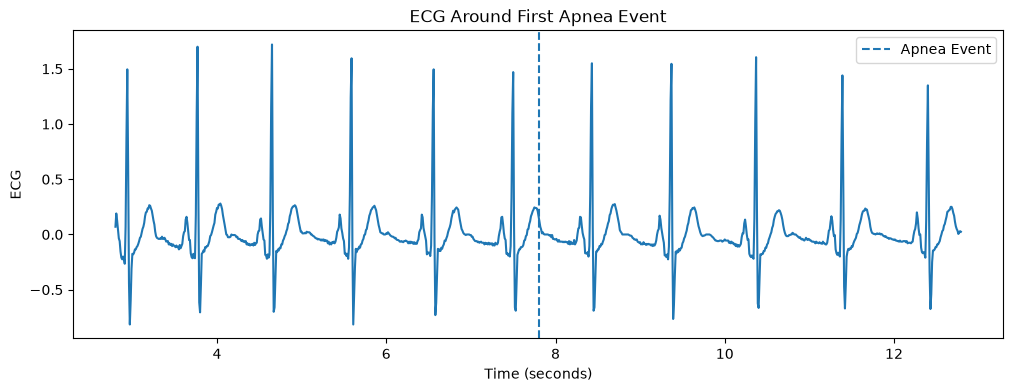

In [13]:
# Plot ECG around the first apnea event

first_apnea = int(apnea_times[0])

window_before = int(5 * record.fs)
window_after = int(5 * record.fs)

start = max(0, first_apnea - window_before)
end = min(record.p_signal.shape[0], first_apnea + window_after)

time = np.arange(start, end) / record.fs

plt.figure(figsize=(12, 4))

plt.plot(time, record.p_signal[start:end, 0])

plt.axvline(
    first_apnea / record.fs,
    linestyle="--",
    label="Apnea Event"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG")
plt.title("ECG Around First Apnea Event")
plt.legend()
plt.show()

In [14]:
# Extract ECG segment around the first apnea event

segment_start = max(0, first_apnea - int(5 * record.fs))
segment_end = min(
    record.p_signal.shape[0],
    first_apnea + int(5 * record.fs)
)

ecg_segment = record.p_signal[segment_start:segment_end, 0]

print("Segment shape:", ecg_segment.shape)
print("Segment start sample:", segment_start)
print("Segment end sample:", segment_end)
print("Segment duration:", len(ecg_segment) / record.fs, "seconds")

Segment shape: (1000,)
Segment start sample: 280
Segment end sample: 1280
Segment duration: 10.0 seconds


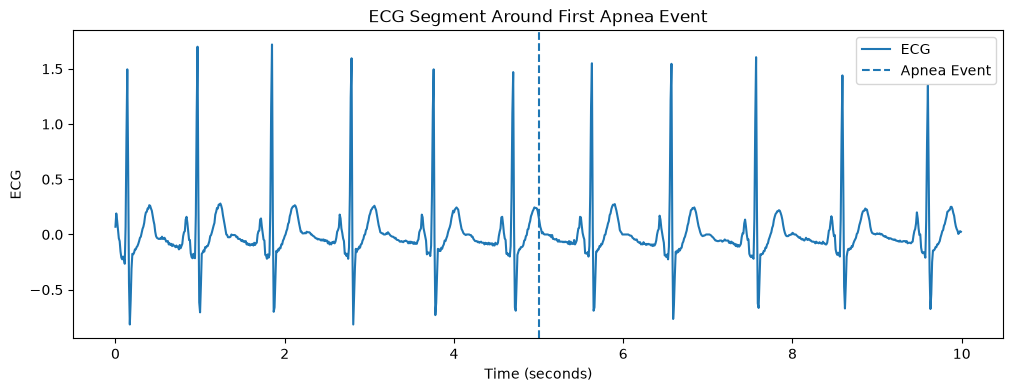

In [15]:
# Plot the extracted ECG segment

segment_time = np.arange(len(ecg_segment)) / record.fs

# Time of apnea event relative to the segment
apnea_time_in_segment = (first_apnea - segment_start) / record.fs

plt.figure(figsize=(12, 4))

plt.plot(segment_time, ecg_segment, label="ECG")

plt.axvline(
    apnea_time_in_segment,
    linestyle="--",
    label="Apnea Event"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG")
plt.title("ECG Segment Around First Apnea Event")
plt.legend()
plt.show()

In [16]:
# Extract ECG segment around the first apnea event

apnea_center = int(apnea_times[0])

segment_duration = int(10 * record.fs)

apnea_start = max(0, apnea_center - segment_duration // 2)
apnea_end = min(
    record.p_signal.shape[0],
    apnea_center + segment_duration // 2
)

apnea_segment = record.p_signal[apnea_start:apnea_end, 0]

apnea_time = np.arange(len(apnea_segment)) / record.fs

print("Apnea center sample:", apnea_center)
print("Apnea center time:", apnea_center / record.fs, "seconds")
print("Apnea segment shape:", apnea_segment.shape)
print("Apnea start time:", apnea_start / record.fs, "seconds")
print("Apnea end time:", apnea_end / record.fs, "seconds")
print("Duration:", len(apnea_segment) / record.fs, "seconds")

Apnea center sample: 780
Apnea center time: 7.8 seconds
Apnea segment shape: (1000,)
Apnea start time: 2.8 seconds
Apnea end time: 12.8 seconds
Duration: 10.0 seconds


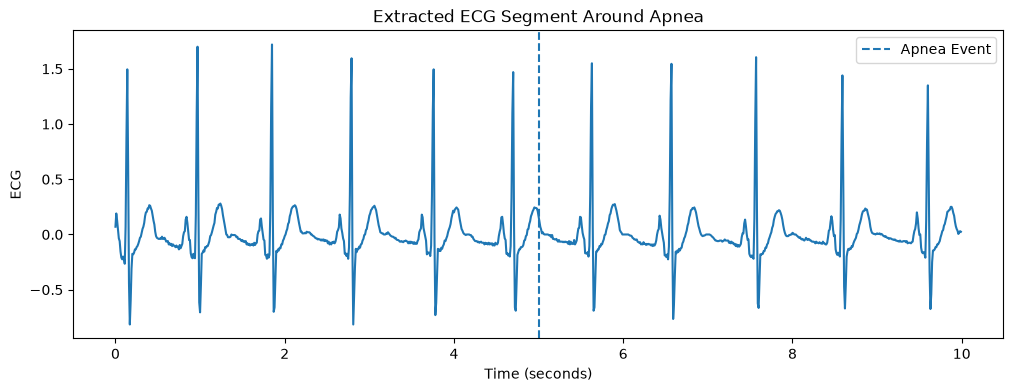

In [17]:
# Plot the extracted apnea ECG segment

plt.figure(figsize=(12, 4))

plt.plot(apnea_time, apnea_segment)

# Apnea occurs at 5 seconds within this extracted segment
plt.axvline(
    5,
    linestyle="--",
    label="Apnea Event"
)

plt.xlabel("Time (seconds)")
plt.ylabel("ECG")
plt.title("Extracted ECG Segment Around Apnea")
plt.legend()
plt.show()

In [18]:
# Extract basic features from the apnea ECG segment

mean_ecg = np.mean(apnea_segment)
std_ecg = np.std(apnea_segment)
min_ecg = np.min(apnea_segment)
max_ecg = np.max(apnea_segment)
rms_ecg = np.sqrt(np.mean(apnea_segment ** 2))

print("Basic ECG Features")
print("------------------")
print("Mean:", mean_ecg)
print("Standard deviation:", std_ecg)
print("Minimum:", min_ecg)
print("Maximum:", max_ecg)
print("RMS:", rms_ecg)

Basic ECG Features
------------------
Mean: 0.0027400000000000002
Standard deviation: 0.25346753717192266
Minimum: -0.815
Maximum: 1.72
RMS: 0.2534823465253547


In [19]:
from scipy.signal import find_peaks

# Detect R-peaks
peaks, properties = find_peaks(
    apnea_segment,
    distance=int(0.4 * record.fs),
    prominence=0.5
)

print("Number of R-peaks:", len(peaks))
print("R-peak sample locations:", peaks)

Number of R-peaks: 11
R-peak sample locations: [ 14  97 185 279 376 470 563 657 757 859 960]


In [20]:
# Calculate R-R intervals

rr_intervals = np.diff(peaks) / record.fs

print("R-R intervals (seconds):")
print(rr_intervals)

print("\nMean R-R interval:", np.mean(rr_intervals), "seconds")

R-R intervals (seconds):
[0.83 0.88 0.94 0.97 0.94 0.93 0.94 1.   1.02 1.01]

Mean R-R interval: 0.946 seconds


In [21]:
# Calculate heart rate from R-R intervals

heart_rate = 60 / rr_intervals

print("Heart rate (BPM):")
print(heart_rate)

print("\nMean heart rate:", np.mean(heart_rate), "BPM")
print("Minimum heart rate:", np.min(heart_rate), "BPM")
print("Maximum heart rate:", np.max(heart_rate), "BPM")

Heart rate (BPM):
[72.28915663 68.18181818 63.82978723 61.8556701  63.82978723 64.51612903
 63.82978723 60.         58.82352941 59.40594059]

Mean heart rate: 63.65616056516269 BPM
Minimum heart rate: 58.8235294117647 BPM
Maximum heart rate: 72.28915662650603 BPM


In [22]:
# Calculate HRV - SDNN

sdnn = np.std(rr_intervals, ddof=1)

print("HRV Features")
print("------------")
print("SDNN:", sdnn, "seconds")

HRV Features
------------
SDNN: 0.05891613625409521 seconds


In [23]:
# Calculate HRV - RMSSD

successive_differences = np.diff(rr_intervals)

rmssd = np.sqrt(np.mean(successive_differences ** 2))

print("HRV Features")
print("----------------")
print("SDNN:", sdnn, "seconds")
print("RMSSD:", rmssd, "seconds")

HRV Features
----------------
SDNN: 0.05891613625409521 seconds
RMSSD: 0.036817870057290876 seconds


In [24]:
# Calculate additional heart-rate features

mean_hr = np.mean(heart_rate)
min_hr = np.min(heart_rate)
max_hr = np.max(heart_rate)
std_hr = np.std(heart_rate)

print("Heart Rate Features")
print("-------------------")
print("Mean HR:", mean_hr, "BPM")
print("Minimum HR:", min_hr, "BPM")
print("Maximum HR:", max_hr, "BPM")
print("HR Standard Deviation:", std_hr, "BPM")

Heart Rate Features
-------------------
Mean HR: 63.65616056516269 BPM
Minimum HR: 58.8235294117647 BPM
Maximum HR: 72.28915662650603 BPM
HR Standard Deviation: 3.9226031144255753 BPM


In [25]:
# Create a feature vector for the current apnea segment

features = {
    "mean_ecg": mean_ecg,
    "std_ecg": std_ecg,
    "min_ecg": min_ecg,
    "max_ecg": max_ecg,
    "rms_ecg": rms_ecg,
    "mean_rr": np.mean(rr_intervals),
    "std_rr": np.std(rr_intervals),
    "mean_hr": mean_hr,
    "min_hr": min_hr,
    "max_hr": max_hr,
    "std_hr": std_hr,
    "sdnn": sdnn,
    "rmssd": rmssd
}

print("Feature Vector")
print("----------------")

for name, value in features.items():
    print(f"{name}: {value}")

Feature Vector
----------------
mean_ecg: 0.0027400000000000002
std_ecg: 0.25346753717192266
min_ecg: -0.815
max_ecg: 1.72
rms_ecg: 0.2534823465253547
mean_rr: 0.946
std_rr: 0.055892754449928486
mean_hr: 63.65616056516269
min_hr: 58.8235294117647
max_hr: 72.28915662650603
std_hr: 3.9226031144255753
sdnn: 0.05891613625409521
rmssd: 0.036817870057290876


In [26]:
def extract_features(ecg_segment, fs):

    # Detect R-peaks
    peaks, _ = find_peaks(
        ecg_segment,
        distance=int(0.4 * fs),
        prominence=0.5
    )

    # Need at least 2 R-peaks to calculate R-R intervals
    if len(peaks) < 2:
        return None

    # R-R intervals in seconds
    rr_intervals = np.diff(peaks) / fs

    # Heart rate in BPM
    heart_rate = 60 / rr_intervals

    # Basic ECG features
    mean_ecg = np.mean(ecg_segment)
    std_ecg = np.std(ecg_segment)
    min_ecg = np.min(ecg_segment)
    max_ecg = np.max(ecg_segment)
    rms_ecg = np.sqrt(np.mean(ecg_segment ** 2))

    # Heart-rate features
    mean_hr = np.mean(heart_rate)
    min_hr = np.min(heart_rate)
    max_hr = np.max(heart_rate)
    std_hr = np.std(heart_rate)

    # HRV features
    sdnn = np.std(rr_intervals)

    successive_differences = np.diff(rr_intervals)
    rmssd = np.sqrt(np.mean(successive_differences ** 2))

    # Store all features
    features = {
        "mean_ecg": mean_ecg,
        "std_ecg": std_ecg,
        "min_ecg": min_ecg,
        "max_ecg": max_ecg,
        "rms_ecg": rms_ecg,
        "mean_rr": np.mean(rr_intervals),
        "std_rr": np.std(rr_intervals),
        "mean_hr": mean_hr,
        "min_hr": min_hr,
        "max_hr": max_hr,
        "std_hr": std_hr,
        "sdnn": sdnn,
        "rmssd": rmssd
    }

    return features

In [27]:
print("apnea_segment exists:", 'apnea_segment' in globals())
print("record exists:", 'record' in globals())

apnea_segment exists: True
record exists: True


In [28]:
test_features = extract_features(
    apnea_segment,
    record.fs
)

print("Extracted Features")
print("------------------")

for name, value in test_features.items():
    print(f"{name}: {value}")

Extracted Features
------------------
mean_ecg: 0.0027400000000000002
std_ecg: 0.25346753717192266
min_ecg: -0.815
max_ecg: 1.72
rms_ecg: 0.2534823465253547
mean_rr: 0.946
std_rr: 0.055892754449928486
mean_hr: 63.65616056516269
min_hr: 58.8235294117647
max_hr: 72.28915662650603
std_hr: 3.9226031144255753
sdnn: 0.055892754449928486
rmssd: 0.036817870057290876


In [29]:
# Store features from all ECG segments
all_features = []

# Store the corresponding labels
all_labels = []

In [30]:
# Extract features from the current apnea segment
apnea_features = extract_features(ecg_segment, record.fs)

# Store the features
all_features.append(apnea_features)

# Label: 1 = apnea
all_labels.append(1)

print("Number of feature samples:", len(all_features))
print("Number of labels:", len(all_labels))

Number of feature samples: 1
Number of labels: 1


In [31]:
# Create multiple 10-second segments from the ECG signal
segment_length = 10 * record.fs

num_segments = len(record.p_signal) // segment_length

print("Total segments available:", num_segments)

Total segments available: 2957


In [32]:
# Create labels for all 10-second ECG segments

all_features = []
all_labels = []

for i in range(num_segments):

    # Start and end sample of this segment
    start = i * segment_length
    end = start + segment_length

    # Extract ECG segment
    segment = record.p_signal[start:end, 0]

    # Time at the center of this segment
    segment_center = (start + segment_length / 2) / record.fs

    # Check whether the segment center is inside an apnea event
    label = 0

    for apnea_time_point in apnea_times:
        if abs(segment_center - apnea_time_point) <= 5:
            label = 1
            break

    # Extract features
    features = extract_features(segment, record.fs)

    all_features.append(features)
    all_labels.append(label)

print("Number of feature samples:", len(all_features))
print("Number of labels:", len(all_labels))

Number of feature samples: 2957
Number of labels: 2957


In [33]:
import numpy as np
import pandas as pd

X = pd.DataFrame(all_features)
y = np.array(all_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (2957, 13)
y shape: (2957,)


In [34]:
unique, counts = np.unique(all_labels, return_counts=True)

for label, count in zip(unique, counts):
    print(f"Label {label}: {count} samples")

Label 0: 2017 samples
Label 1: 940 samples


In [35]:
from sklearn.model_selection import train_test_split
import numpy as np

# Check original labels first
print("Original labels:", np.unique(y, return_counts=True))

# Split the data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Check shapes
print("\nShapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

# Check labels after splitting
print("\nTraining labels:", np.unique(y_train, return_counts=True))
print("Testing labels:", np.unique(y_test, return_counts=True))

Original labels: (array([0, 1]), array([2017,  940]))

Shapes:
X_train: (2365, 13)
X_test: (592, 13)
y_train: (2365,)
y_test: (592,)

Training labels: (array([0, 1]), array([1613,  752]))
Testing labels: (array([0, 1]), array([404, 188]))


In [36]:
from sklearn.ensemble import RandomForestClassifier

In [37]:
# Create Random Forest classifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

print("Random Forest model created successfully!")

Random Forest model created successfully!


In [38]:
# Train the Random Forest model

model.fit(X_train, y_train)

print("Random Forest trained successfully!")

Random Forest trained successfully!


In [39]:
# Make predictions on the test set

y_pred = model.predict(X_test)

print("Predictions completed successfully!")
print("Number of predictions:", len(y_pred))

Predictions completed successfully!
Number of predictions: 592


In [40]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [41]:
# Evaluate the Random Forest model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.6453
Precision: 0.2885
Recall   : 0.0798
F1-score : 0.1250


In [42]:
# Evaluate the Random Forest model

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Random Forest Performance")
print("-------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

Random Forest Performance
-------------------------
Accuracy : 0.6453
Precision: 0.2885
Recall   : 0.0798
F1-score : 0.1250


In [43]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[367  37]
 [173  15]]


In [44]:
# Detailed classification report
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    y_pred,
    target_names=["Normal", "Apnea"]
))

              precision    recall  f1-score   support

      Normal       0.68      0.91      0.78       404
       Apnea       0.29      0.08      0.12       188

    accuracy                           0.65       592
   macro avg       0.48      0.49      0.45       592
weighted avg       0.56      0.65      0.57       592



In [45]:
# Create a balanced Random Forest

balanced_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

print("Balanced Random Forest created successfully!")

Balanced Random Forest created successfully!


In [46]:
# Train the balanced Random Forest

balanced_model.fit(X_train, y_train)

print("Balanced Random Forest trained successfully!")

Balanced Random Forest trained successfully!


In [47]:
# Balanced Random Forest predictions

y_pred_balanced_rf = balanced_model.predict(X_test)

print("Balanced Random Forest predictions generated successfully.")
print("Number of predictions:", len(y_pred_balanced_rf))

Balanced Random Forest predictions generated successfully.
Number of predictions: 592


In [48]:
# Evaluate Balanced Random Forest

accuracy_balanced_rf = accuracy_score(y_test, y_pred_balanced_rf)
precision_balanced_rf = precision_score(
    y_test, y_pred_balanced_rf, zero_division=0
)
recall_balanced_rf = recall_score(
    y_test, y_pred_balanced_rf, zero_division=0
)
f1_balanced_rf = f1_score(
    y_test, y_pred_balanced_rf, zero_division=0
)

print("Balanced Random Forest Performance")
print("----------------------------------")
print(f"Accuracy : {accuracy_balanced_rf:.4f}")
print(f"Precision: {precision_balanced_rf:.4f}")
print(f"Recall   : {recall_balanced_rf:.4f}")
print(f"F1-score : {f1_balanced_rf:.4f}")

Balanced Random Forest Performance
----------------------------------
Accuracy : 0.6081
Precision: 0.3533
Recall   : 0.2819
F1-score : 0.3136


In [49]:
# Confusion Matrix - Balanced Random Forest

cm_balanced_rf = confusion_matrix(y_test, y_pred_balanced_rf)

print("Confusion Matrix:")
print(cm_balanced_rf)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_balanced_rf,
    target_names=["Normal", "Apnea"],
    zero_division=0
))

Confusion Matrix:
[[307  97]
 [135  53]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.69      0.76      0.73       404
       Apnea       0.35      0.28      0.31       188

    accuracy                           0.61       592
   macro avg       0.52      0.52      0.52       592
weighted avg       0.59      0.61      0.59       592



In [50]:
print("Random Forest Comparison")
print("========================")

print(f"Normal RF:")
print(f"  Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  Recall   : {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"  F1-score : {f1_score(y_test, y_pred, zero_division=0):.4f}")

print("\nBalanced RF:")
print(f"  Accuracy : {accuracy_balanced_rf:.4f}")
print(f"  Precision: {precision_balanced_rf:.4f}")
print(f"  Recall   : {recall_balanced_rf:.4f}")
print(f"  F1-score : {f1_balanced_rf:.4f}")

Random Forest Comparison
Normal RF:
  Accuracy : 0.6453
  Precision: 0.2885
  Recall   : 0.0798
  F1-score : 0.1250

Balanced RF:
  Accuracy : 0.6081
  Precision: 0.3533
  Recall   : 0.2819
  F1-score : 0.3136


In [51]:
print("Balanced RF expects:", balanced_model.n_features_in_, "features")
print("X_train has:", X_train.shape[1], "features")
print("X has:", X.shape[1], "features")

Balanced RF expects: 13 features
X_train has: 13 features
X has: 13 features


In [52]:
# Recreate train-test split using all 13 features

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("Number of features:", X_train.shape[1])

X_train shape: (2365, 13)
X_test shape: (592, 13)
Number of features: 13


In [53]:
# Train Normal Random Forest using all 13 features

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

print("Normal Random Forest trained successfully.")
print("Features used:", model.n_features_in_)

Normal Random Forest trained successfully.
Features used: 13


In [54]:
# Train Balanced Random Forest using all 13 features

balanced_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

balanced_model.fit(X_train, y_train)

print("Balanced Random Forest trained successfully.")
print("Features used:", balanced_model.n_features_in_)

Balanced Random Forest trained successfully.
Features used: 13


In [55]:
# Generate predictions from the corrected Balanced Random Forest

y_pred_balanced_rf = balanced_model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred_balanced_rf))

Predictions generated successfully.
Number of predictions: 592


In [56]:
# Evaluate Corrected Balanced Random Forest

accuracy_balanced_rf = accuracy_score(y_test, y_pred_balanced_rf)
precision_balanced_rf = precision_score(
    y_test, y_pred_balanced_rf, zero_division=0
)
recall_balanced_rf = recall_score(
    y_test, y_pred_balanced_rf, zero_division=0
)
f1_balanced_rf = f1_score(
    y_test, y_pred_balanced_rf, zero_division=0
)

print("Corrected Balanced Random Forest Performance")
print("---------------------------------------------")
print(f"Accuracy : {accuracy_balanced_rf:.4f}")
print(f"Precision: {precision_balanced_rf:.4f}")
print(f"Recall   : {recall_balanced_rf:.4f}")
print(f"F1-score : {f1_balanced_rf:.4f}")

Corrected Balanced Random Forest Performance
---------------------------------------------
Accuracy : 0.6081
Precision: 0.3533
Recall   : 0.2819
F1-score : 0.3136


In [57]:
# Confusion Matrix - Corrected Balanced Random Forest

cm_balanced_rf = confusion_matrix(y_test, y_pred_balanced_rf)

print("Confusion Matrix:")
print(cm_balanced_rf)

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred_balanced_rf,
    target_names=["Normal", "Apnea"],
    zero_division=0
))

Confusion Matrix:
[[307  97]
 [135  53]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.69      0.76      0.73       404
       Apnea       0.35      0.28      0.31       188

    accuracy                           0.61       592
   macro avg       0.52      0.52      0.52       592
weighted avg       0.59      0.61      0.59       592



In [58]:
# Feature Importance - Corrected 13-Feature Balanced RF

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": balanced_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print(feature_importance)

     Feature  Importance
0      rmssd    0.093883
1   mean_ecg    0.092083
2    max_ecg    0.081018
3    rms_ecg    0.080594
4    std_ecg    0.079630
5    mean_hr    0.078279
6     std_rr    0.077366
7     std_hr    0.077112
8       sdnn    0.077042
9    mean_rr    0.072846
10   min_ecg    0.071433
11    min_hr    0.062371
12    max_hr    0.056344


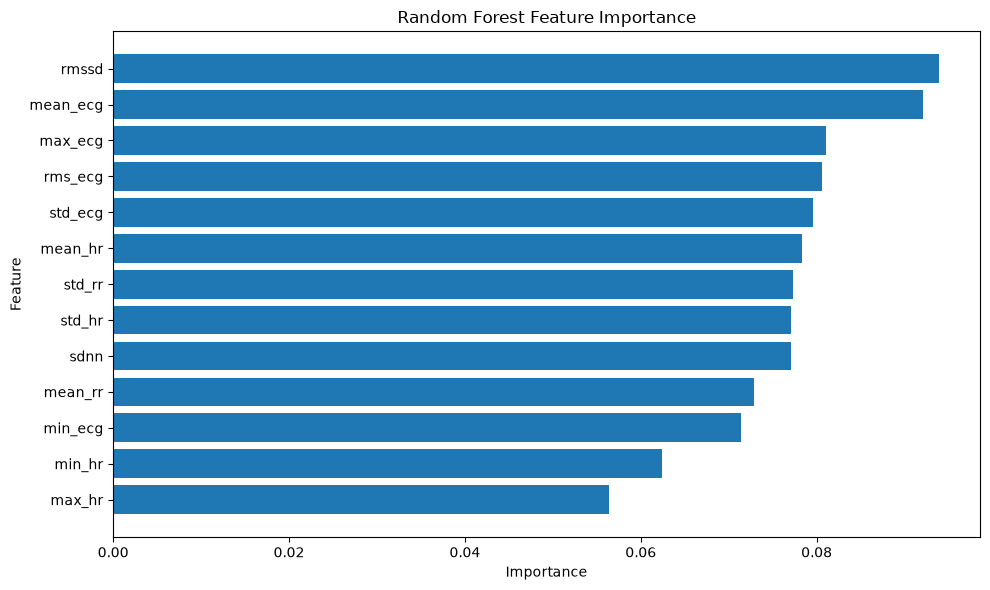

In [59]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [60]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance
perm_result = permutation_importance(
    balanced_model,
    X_test,
    y_test,
    scoring="f1",
    n_repeats=10,
    random_state=42
)

permutation_importance_df = pd.DataFrame({
    "Feature": X.columns,
    "Importance": perm_result.importances_mean
})

permutation_importance_df = permutation_importance_df.sort_values(
    by="Importance",
    ascending=False
).reset_index(drop=True)

print(permutation_importance_df)

     Feature  Importance
0    mean_rr    0.070962
1     std_hr    0.066731
2    mean_hr    0.061719
3       sdnn    0.052161
4    min_ecg    0.050415
5     std_rr    0.046813
6    rms_ecg    0.040244
7    std_ecg    0.037767
8     min_hr    0.033183
9     max_hr    0.023087
10  mean_ecg    0.020323
11   max_ecg    0.004210
12     rmssd    0.003049


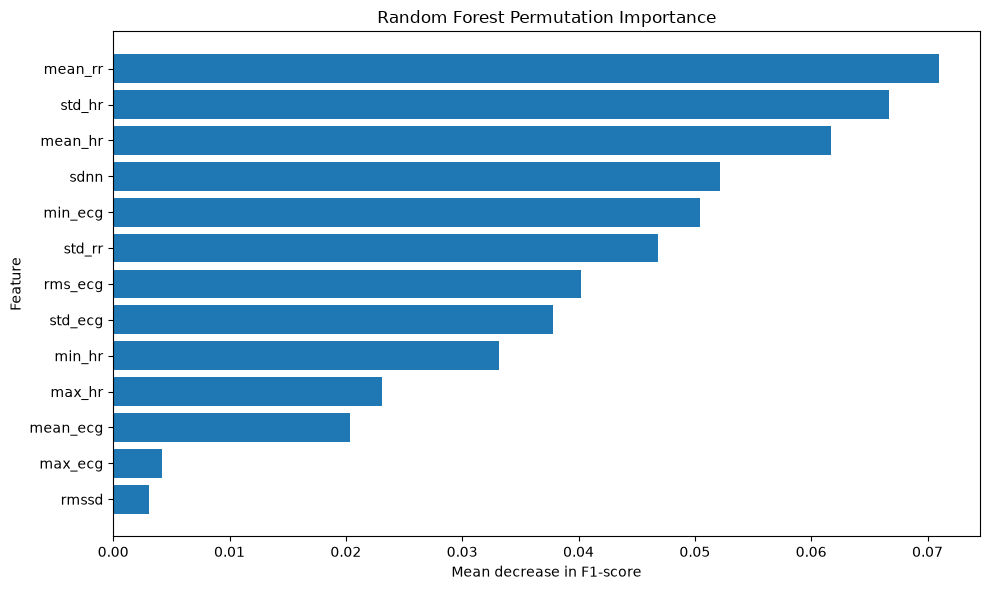

In [61]:
plt.figure(figsize=(10, 6))

plt.barh(
    permutation_importance_df["Feature"],
    permutation_importance_df["Importance"]
)

plt.xlabel("Mean decrease in F1-score")
plt.ylabel("Feature")
plt.title("Random Forest Permutation Importance")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [62]:
# Select top 3 features from permutation importance

selected_features_rf = ["mean_rr", "std_hr", "mean_hr"]

X_selected = X[selected_features_rf]

X_train_selected, X_test_selected, y_train_selected, y_test_selected = train_test_split(
    X_selected,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Selected features:", selected_features_rf)
print("Training shape:", X_train_selected.shape)
print("Testing shape:", X_test_selected.shape)

Selected features: ['mean_rr', 'std_hr', 'mean_hr']
Training shape: (2365, 3)
Testing shape: (592, 3)


In [63]:
# Train Balanced Random Forest with Top 3 Features

rf_selected = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42
)

rf_selected.fit(X_train_selected, y_train_selected)

print("3-feature Balanced Random Forest trained successfully.")
print("Features used:", rf_selected.n_features_in_)

3-feature Balanced Random Forest trained successfully.
Features used: 3


In [64]:
# Predict using the 3-feature Balanced Random Forest

y_pred_selected = rf_selected.predict(X_test_selected)

print("Number of predictions:", len(y_pred_selected))

Number of predictions: 592


In [65]:
# Evaluate 3-Feature Balanced Random Forest

accuracy_selected = accuracy_score(y_test_selected, y_pred_selected)
precision_selected = precision_score(
    y_test_selected, y_pred_selected, zero_division=0
)
recall_selected = recall_score(
    y_test_selected, y_pred_selected, zero_division=0
)
f1_selected = f1_score(
    y_test_selected, y_pred_selected, zero_division=0
)

print("3-Feature Balanced Random Forest Performance")
print("---------------------------------------------")
print(f"Accuracy : {accuracy_selected:.4f}")
print(f"Precision: {precision_selected:.4f}")
print(f"Recall   : {recall_selected:.4f}")
print(f"F1-score : {f1_selected:.4f}")

3-Feature Balanced Random Forest Performance
---------------------------------------------
Accuracy : 0.5676
Precision: 0.3265
Recall   : 0.3404
F1-score : 0.3333


In [66]:
# Confusion Matrix - 3 Feature Random Forest

cm_selected = confusion_matrix(
    y_test_selected,
    y_pred_selected
)

print("Confusion Matrix:")
print(cm_selected)

print("\nClassification Report:")
print(classification_report(
    y_test_selected,
    y_pred_selected,
    target_names=["Normal", "Apnea"],
    zero_division=0
))

Confusion Matrix:
[[272 132]
 [124  64]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.69      0.67      0.68       404
       Apnea       0.33      0.34      0.33       188

    accuracy                           0.57       592
   macro avg       0.51      0.51      0.51       592
weighted avg       0.57      0.57      0.57       592



In [67]:
import numpy as np
import pandas as pd

# Convert features and labels into arrays
X = X.to_numpy()
y = np.array(all_labels)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Unique labels:", np.unique(y, return_counts=True))

X shape: (2957, 13)
y shape: (2957,)
Unique labels: (array([0, 1]), array([2017,  940]))


In [68]:
# Check class distribution in training and testing sets

unique_train, counts_train = np.unique(y_train, return_counts=True)
unique_test, counts_test = np.unique(y_test, return_counts=True)

print("Training set:")
for label, count in zip(unique_train, counts_train):
    print(f"Label {label}: {count} samples")

print("\nTesting set:")
for label, count in zip(unique_test, counts_test):
    print(f"Label {label}: {count} samples")

Training set:
Label 0: 1613 samples
Label 1: 752 samples

Testing set:
Label 0: 404 samples
Label 1: 188 samples


In [69]:
print("Unique values in y_train:", np.unique(y_train))
print("Unique values in y_test:", np.unique(y_test))

print("y_train first 20:", y_train[:20])
print("y_test first 20:", y_test[:20])

Unique values in y_train: [0 1]
Unique values in y_test: [0 1]
y_train first 20: [0 0 0 0 0 1 0 0 0 1 0 0 0 1 1 0 0 0 1 1]
y_test first 20: [1 1 0 0 0 0 1 0 0 0 1 1 0 0 0 0 0 0 0 0]


In [70]:
print("Number of apnea times:", len(apnea_times))
print("First 20 apnea times:", apnea_times[:20])

Number of apnea times: 470
First 20 apnea times: [ 780.  840.  900.  960. 1020. 1080. 1140. 1200. 1260. 1320. 1380. 1440.
 1500. 1560. 1620. 1680. 1740. 1800. 1860. 1920.]


In [71]:
print("ECG sampling frequency:", record.fs)
print("Number of segments:", num_segments)
print("Segment length:", segment_length)
print("Total ECG duration:", len(record.p_signal) / record.fs)

print("\nFirst 10 segment centers:")

for i in range(10):
    start = i * segment_length
    segment_center = (start + segment_length / 2) / record.fs
    print(i, "->", segment_center)

ECG sampling frequency: 100
Number of segments: 2957
Segment length: 1000
Total ECG duration: 29570.0

First 10 segment centers:
0 -> 5.0
1 -> 15.0
2 -> 25.0
3 -> 35.0
4 -> 45.0
5 -> 55.0
6 -> 65.0
7 -> 75.0
8 -> 85.0
9 -> 95.0


In [72]:
# Test whether apnea times match our ECG segment centers

matches = []

for i in range(num_segments):
    start = i * segment_length
    segment_center = (start + segment_length / 2) / record.fs

    for apnea_time_point in apnea_times:
        if abs(segment_center - apnea_time_point) <= 5:
            matches.append((i, segment_center, apnea_time_point))
            break

print("Number of matching segments:", len(matches))
print("First 10 matches:")

for match in matches[:10]:
    print(match)

Number of matching segments: 940
First 10 matches:
(77, 775.0, np.float64(780.0))
(78, 785.0, np.float64(780.0))
(83, 835.0, np.float64(840.0))
(84, 845.0, np.float64(840.0))
(89, 895.0, np.float64(900.0))
(90, 905.0, np.float64(900.0))
(95, 955.0, np.float64(960.0))
(96, 965.0, np.float64(960.0))
(101, 1015.0, np.float64(1020.0))
(102, 1025.0, np.float64(1020.0))


In [73]:
print("Total ECG segments:", num_segments)
print("Total apnea time points:", len(apnea_times))
print("Matching segments:", len(matches))

Total ECG segments: 2957
Total apnea time points: 470
Matching segments: 940


In [74]:
# Create labels for all 10-second ECG segments
# 0 = Normal
# 1 = Apnea

segment_labels = np.zeros(num_segments, dtype=int)

for i in range(num_segments):
    start = i * segment_length
    segment_center = (start + segment_length / 2) / record.fs

    for apnea_time_point in apnea_times:
        if abs(segment_center - apnea_time_point) <= 5:
            segment_labels[i] = 1
            break

print("Total segments:", len(segment_labels))
print("Normal segments:", np.sum(segment_labels == 0))
print("Apnea segments:", np.sum(segment_labels == 1))

Total segments: 2957
Normal segments: 2017
Apnea segments: 940


In [75]:
print("Training set:")
unique_train, counts_train = np.unique(y_train, return_counts=True)

for label, count in zip(unique_train, counts_train):
    print(f"Label {label}: {count} samples")

print("\nTesting set:")
unique_test, counts_test = np.unique(y_test, return_counts=True)

for label, count in zip(unique_test, counts_test):
    print(f"Label {label}: {count} samples")

Training set:
Label 0: 1613 samples
Label 1: 752 samples

Testing set:
Label 0: 404 samples
Label 1: 188 samples


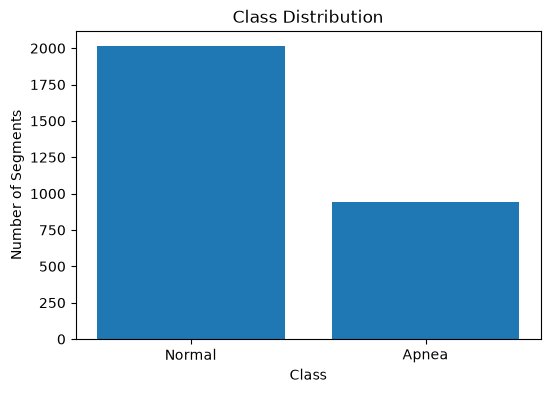

In [76]:
import matplotlib.pyplot as plt

# Count each class
normal_count = np.sum(segment_labels == 0)
apnea_count = np.sum(segment_labels == 1)

# Plot
plt.figure(figsize=(6, 4))

plt.bar(
    ["Normal", "Apnea"],
    [normal_count, apnea_count]
)

plt.xlabel("Class")
plt.ylabel("Number of Segments")
plt.title("Class Distribution")

plt.show()

In [77]:
# Show variables related to ECG/segments
[name for name in globals() if "segment" in name.lower() or "ecg" in name.lower()]

['ecg',
 'ecg_segment',
 'segment_start',
 'segment_end',
 'segment_time',
 'apnea_time_in_segment',
 'segment_duration',
 'apnea_segment',
 'mean_ecg',
 'std_ecg',
 'min_ecg',
 'max_ecg',
 'rms_ecg',
 'segment_length',
 'num_segments',
 'segment',
 'segment_center',
 'segment_labels']

In [78]:
# Find one normal segment and one apnea segment
normal_index = np.where(segment_labels == 0)[0][0]
apnea_index = np.where(segment_labels == 1)[0][0]

# Get their starting positions
normal_start = normal_index * segment_length
apnea_start = apnea_index * segment_length

# Extract the ECG signals
normal_segment = ecg[normal_start:normal_start + segment_length]
apnea_segment = ecg[apnea_start:apnea_start + segment_length]

print("Normal segment index:", normal_index)
print("Apnea segment index:", apnea_index)
print("Samples per segment:", segment_length)

Normal segment index: 0
Apnea segment index: 77
Samples per segment: 1000


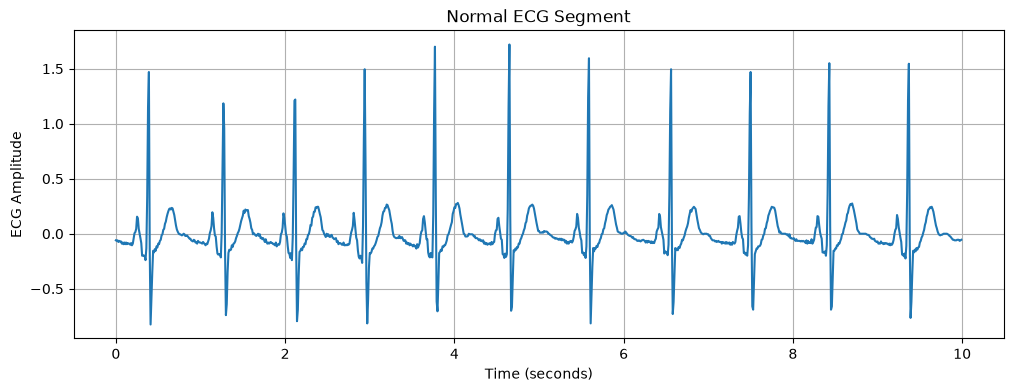

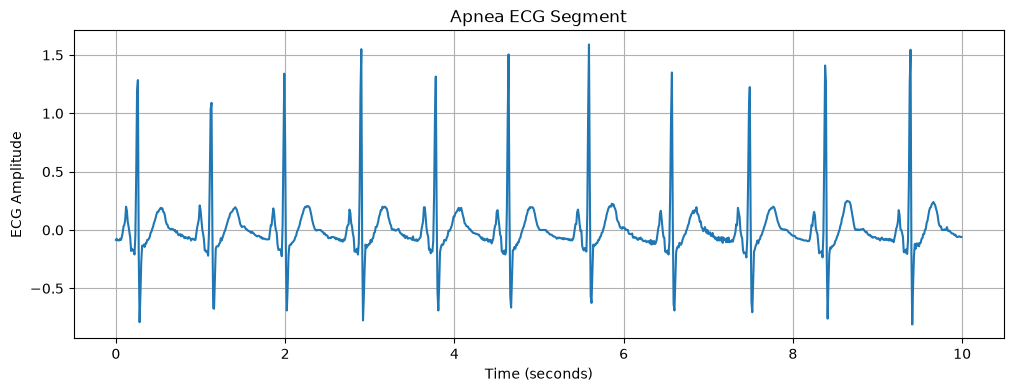

In [79]:
import matplotlib.pyplot as plt

# Create time axis in seconds
time = np.arange(segment_length) / record.fs

# Plot normal ECG
plt.figure(figsize=(12, 4))
plt.plot(time, normal_segment)
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("Normal ECG Segment")
plt.grid(True)
plt.show()

# Plot apnea ECG
plt.figure(figsize=(12, 4))
plt.plot(time, apnea_segment)
plt.xlabel("Time (seconds)")
plt.ylabel("ECG Amplitude")
plt.title("Apnea ECG Segment")
plt.grid(True)
plt.show()

In [80]:
# Compare ECG features between Normal and Apnea segments

import pandas as pd
import matplotlib.pyplot as plt

# Create a DataFrame from all extracted features
features_df = pd.DataFrame(all_features)

# Add class labels
features_df["label"] = segment_labels

# Convert labels to readable names
features_df["class"] = features_df["label"].map({
    0: "Normal",
    1: "Apnea"
})

print("Feature DataFrame shape:", features_df.shape)
print("\nFirst 5 rows:")
display(features_df.head())

Feature DataFrame shape: (2957, 15)

First 5 rows:


,mean_ecg,std_ecg,min_ecg,max_ecg,rms_ecg,mean_rr,std_rr,mean_hr,min_hr,max_hr,std_hr,sdnn,rmssd,label,class
0,-0.000080,0.255133,-0.825,1.720,0.255133,0.898000,0.050160,67.027292,61.855670,73.170732,3.801302,0.050160,0.033333,0,Normal
1,0.000220,0.235173,-0.720,1.640,0.235174,0.974444,0.036851,61.663998,58.823529,66.666667,2.393605,0.036851,0.034641,0,Normal
2,-0.001980,0.268365,-0.885,1.750,0.268372,0.826364,0.099843,73.867377,61.855670,103.448276,10.613667,0.099843,0.129692,0,Normal
3,0.000605,0.256633,-0.845,1.710,0.256634,0.891000,0.045486,67.507382,60.000000,72.289157,3.283998,0.045486,0.052493,0,Normal
4,-0.003740,0.253203,-0.810,1.665,0.253230,0.898000,0.054918,67.059875,60.000000,73.170732,4.008264,0.054918,0.041500,0,Normal


In [81]:
# Extract features for all ECG segments

all_features = []

for i in range(num_segments):

    start = i * segment_length
    end = start + segment_length

    ecg_segment = ecg[start:end]

    features = extract_features(
        ecg_segment,
        record.fs
    )

    all_features.append(features)

print("Total feature records:", len(all_features))
print("First feature record:", all_features[0])

Total feature records: 2957
First feature record: {'mean_ecg': np.float64(-8.000000000000052e-05), 'std_ecg': np.float64(0.25513328595069673), 'min_ecg': np.float64(-0.825), 'max_ecg': np.float64(1.72), 'rms_ecg': np.float64(0.25513329849316024), 'mean_rr': np.float64(0.8979999999999999), 'std_rr': np.float64(0.05015974481593781), 'mean_hr': np.float64(67.02729208290556), 'min_hr': np.float64(61.855670103092784), 'max_hr': np.float64(73.17073170731707), 'std_hr': np.float64(3.801302040329533), 'sdnn': np.float64(0.05015974481593781), 'rmssd': np.float64(0.03333333333333333)}


In [82]:
# Create DataFrame using the extracted features

features_df = pd.DataFrame(all_features)

# Add the corresponding class label
features_df["label"] = segment_labels

# Convert numeric labels to class names
features_df["class"] = features_df["label"].map({
    0: "Normal",
    1: "Apnea"
})

print("Feature DataFrame shape:", features_df.shape)

display(features_df.head())

Feature DataFrame shape: (2957, 15)


,mean_ecg,std_ecg,min_ecg,max_ecg,rms_ecg,mean_rr,std_rr,mean_hr,min_hr,max_hr,std_hr,sdnn,rmssd,label,class
0,-0.000080,0.255133,-0.825,1.720,0.255133,0.898000,0.050160,67.027292,61.855670,73.170732,3.801302,0.050160,0.033333,0,Normal
1,0.000220,0.235173,-0.720,1.640,0.235174,0.974444,0.036851,61.663998,58.823529,66.666667,2.393605,0.036851,0.034641,0,Normal
2,-0.001980,0.268365,-0.885,1.750,0.268372,0.826364,0.099843,73.867377,61.855670,103.448276,10.613667,0.099843,0.129692,0,Normal
3,0.000605,0.256633,-0.845,1.710,0.256634,0.891000,0.045486,67.507382,60.000000,72.289157,3.283998,0.045486,0.052493,0,Normal
4,-0.003740,0.253203,-0.810,1.665,0.253230,0.898000,0.054918,67.059875,60.000000,73.170732,4.008264,0.054918,0.041500,0,Normal


In [83]:
# Compare average feature values between Normal and Apnea

feature_columns = [
    col for col in features_df.columns
    if col not in ["label", "class"]
]

comparison = features_df.groupby("class")[feature_columns].mean()

print("Average feature values:")
display(comparison)

Average feature values:


,mean_ecg,std_ecg,min_ecg,max_ecg,rms_ecg,mean_rr,std_rr,mean_hr,min_hr,max_hr,std_hr,sdnn,rmssd
class,,,,,,,,,,,,,
Apnea,0.000698,0.243296,-0.869617,1.801936,0.243333,1.005962,0.077204,61.360437,53.714174,69.173937,5.019005,0.077204,0.072317
Normal,0.000501,0.243420,-0.865982,1.792300,0.243460,1.002940,0.070343,61.415971,54.498258,68.521464,4.530744,0.070343,0.068566


In [84]:
# Calculate the difference between Apnea and Normal feature means

feature_difference = comparison.loc["Apnea"] - comparison.loc["Normal"]

feature_difference = feature_difference.sort_values(
    key=lambda x: abs(x),
    ascending=False
)

print("Feature differences (Apnea - Normal):")
display(feature_difference)

Feature differences (Apnea - Normal):


min_hr     -0.784084
max_hr      0.652473
std_hr      0.488261
mean_hr    -0.055534
max_ecg     0.009636
sdnn        0.006861
std_rr      0.006861
rmssd       0.003751
min_ecg    -0.003635
mean_rr     0.003022
mean_ecg    0.000197
rms_ecg    -0.000127
std_ecg    -0.000124
dtype: float64

In [85]:
# Calculate Cohen's d for each feature
# This measures how strongly each feature differs between
# Normal and Apnea relative to the variation within each class.

import numpy as np

normal_data = features_df[features_df["label"] == 0]
apnea_data = features_df[features_df["label"] == 1]

effect_sizes = {}

for feature in feature_columns:

    normal_values = normal_data[feature]
    apnea_values = apnea_data[feature]

    mean_normal = normal_values.mean()
    mean_apnea = apnea_values.mean()

    std_normal = normal_values.std()
    std_apnea = apnea_values.std()

    pooled_std = np.sqrt(
        ((len(normal_values) - 1) * std_normal**2 +
         (len(apnea_values) - 1) * std_apnea**2)
        /
        (len(normal_values) + len(apnea_values) - 2)
    )

    if pooled_std != 0:
        cohens_d = (mean_apnea - mean_normal) / pooled_std
    else:
        cohens_d = 0

    effect_sizes[feature] = cohens_d

effect_sizes = pd.Series(effect_sizes)

# Sort by absolute effect size
effect_sizes = effect_sizes.reindex(
    effect_sizes.abs().sort_values(ascending=False).index
)

print("Feature importance based on Cohen's d:")
display(effect_sizes)

Feature importance based on Cohen's d:


std_rr      0.147078
sdnn        0.147078
std_hr      0.139846
min_hr     -0.112173
rmssd       0.099046
max_ecg     0.068759
max_hr      0.052173
mean_ecg    0.045413
min_ecg    -0.042522
mean_rr     0.022506
mean_hr    -0.006334
rms_ecg    -0.005609
std_ecg    -0.005493
dtype: float64

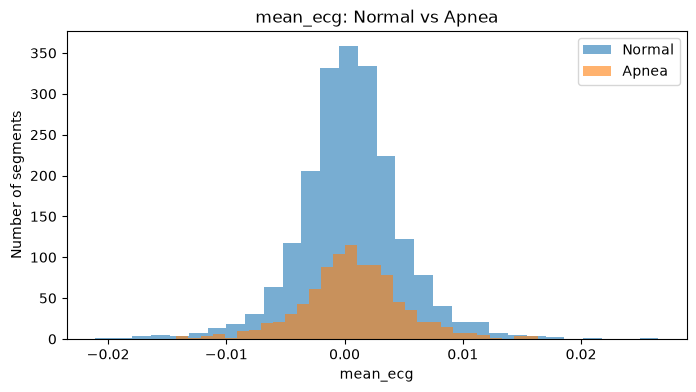

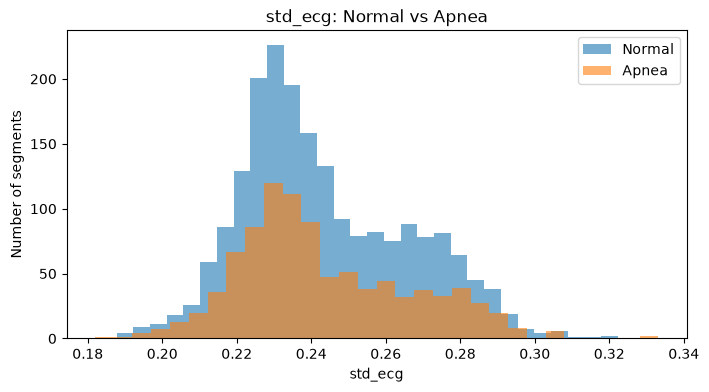

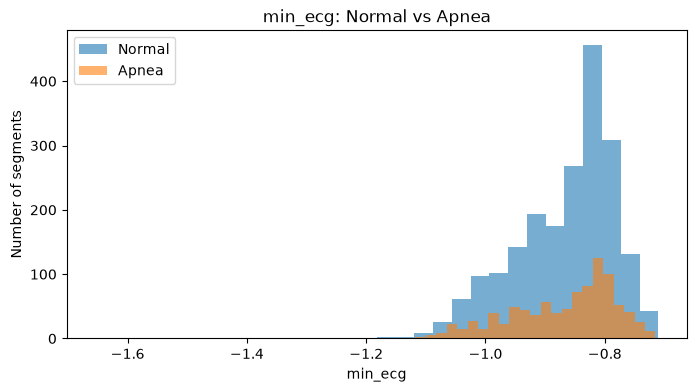

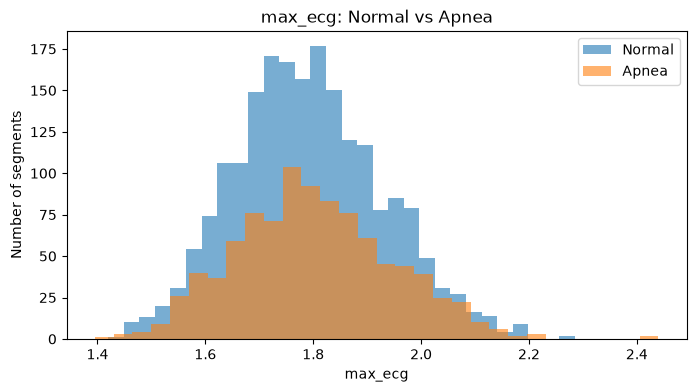

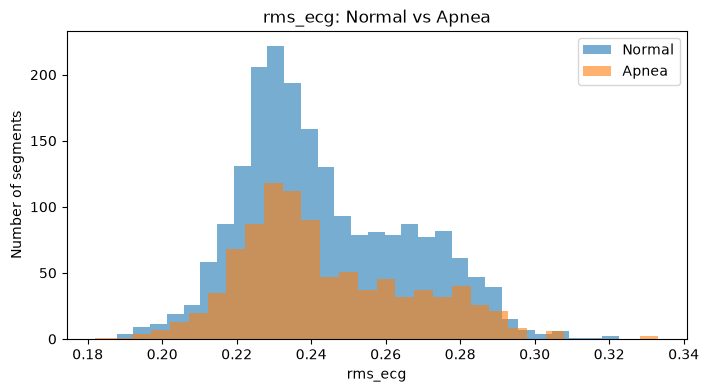

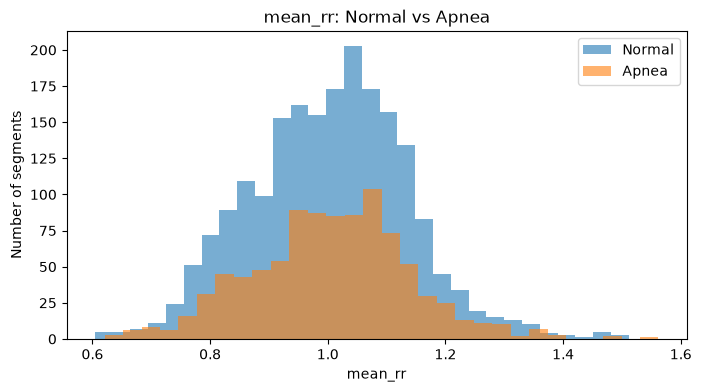

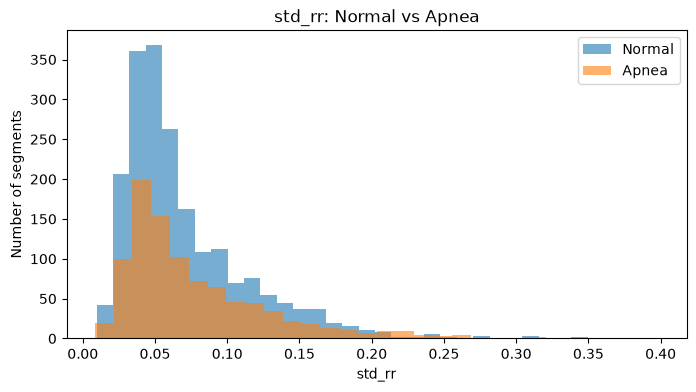

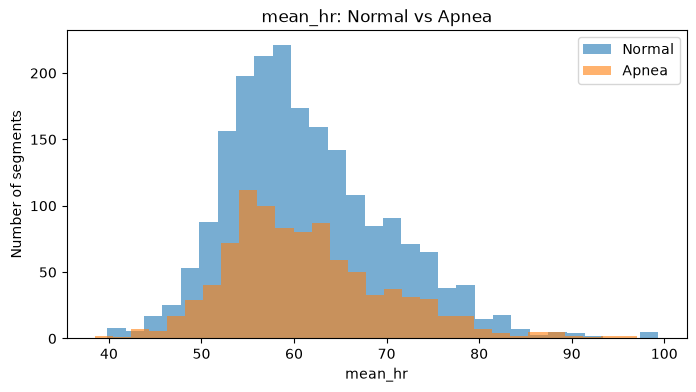

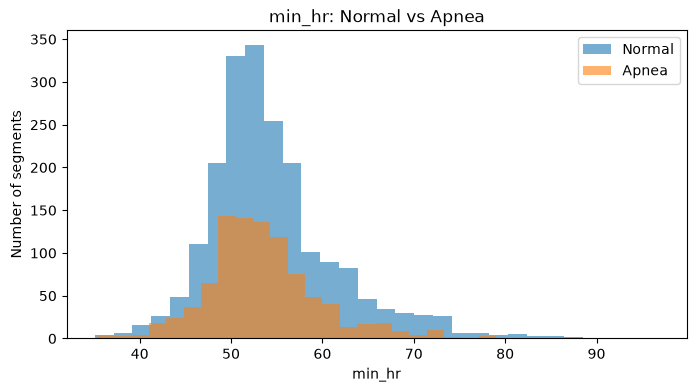

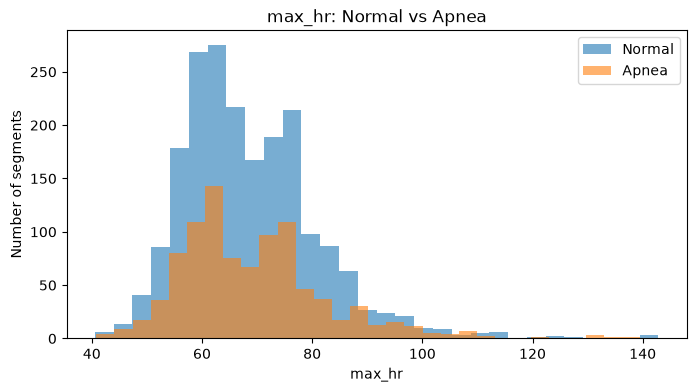

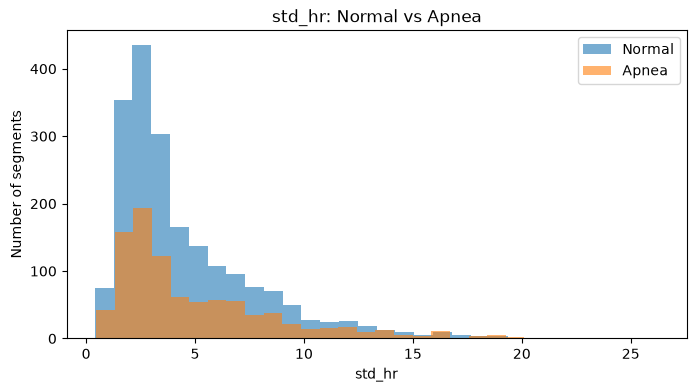

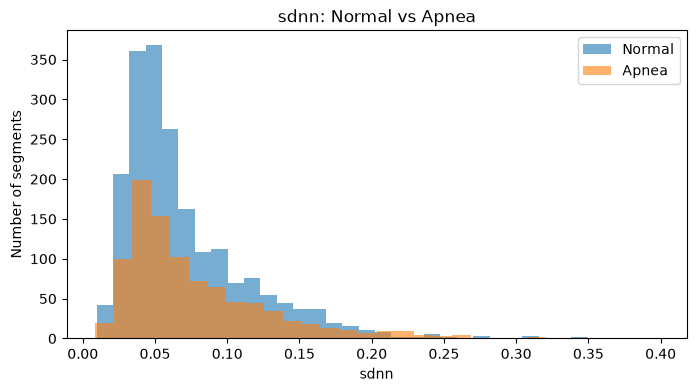

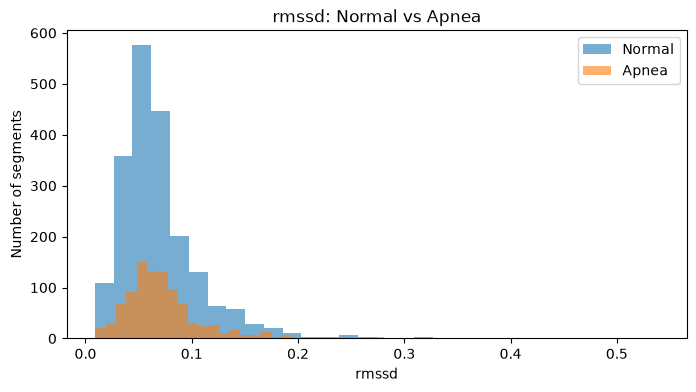

In [86]:
# Compare feature distributions between Normal and Apnea

import matplotlib.pyplot as plt

for feature in feature_columns:
    
    plt.figure(figsize=(8, 4))
    
    plt.hist(
        normal_data[feature],
        bins=30,
        alpha=0.6,
        label="Normal"
    )
    
    plt.hist(
        apnea_data[feature],
        bins=30,
        alpha=0.6,
        label="Apnea"
    )
    
    plt.xlabel(feature)
    plt.ylabel("Number of segments")
    plt.title(f"{feature}: Normal vs Apnea")
    plt.legend()
    plt.show()

In [87]:
from scipy.stats import mannwhitneyu

# Store statistical test results
statistical_results = []

for feature in feature_columns:
    
    normal_values = features_df[features_df["class"] == "Normal"][feature]
    apnea_values = features_df[features_df["class"] == "Apnea"][feature]
    
    statistic, p_value = mannwhitneyu(
        normal_values,
        apnea_values,
        alternative="two-sided"
    )
    
    statistical_results.append({
        "feature": feature,
        "U_statistic": statistic,
        "p_value": p_value
    })

# Convert results to DataFrame
stats_df = pd.DataFrame(statistical_results)

# Sort by p-value
stats_df = stats_df.sort_values("p_value")

print("Statistical significance results:")
display(stats_df)

Statistical significance results:


,feature,U_statistic,p_value
12,rmssd,858704.5,0.000036
6,std_rr,880277.0,0.001735
11,sdnn,880277.0,0.001735
10,std_hr,898602.0,0.022342
8,min_hr,997274.0,0.022578
3,max_ecg,913006.0,0.105593
0,mean_ecg,918561.5,0.173437
9,max_hr,932089.5,0.461947
2,min_ecg,960896.0,0.550435
5,mean_rr,935389.5,0.560004


In [88]:
from scipy.stats import false_discovery_control

# Get the p-values
p_values = stats_df["p_value"].to_numpy()

# Apply Benjamini-Hochberg FDR correction
adjusted_p_values = false_discovery_control(
    p_values,
    method="bh"
)

# Add corrected p-values
stats_df["p_adjusted"] = adjusted_p_values

# Sort by corrected p-value
stats_df = stats_df.sort_values("p_adjusted")

print("FDR-corrected results:")
display(stats_df)

FDR-corrected results:


,feature,U_statistic,p_value,p_adjusted
12,rmssd,858704.5,0.000036,0.000472
6,std_rr,880277.0,0.001735,0.007520
11,sdnn,880277.0,0.001735,0.007520
10,std_hr,898602.0,0.022342,0.058703
8,min_hr,997274.0,0.022578,0.058703
3,max_ecg,913006.0,0.105593,0.228784
0,mean_ecg,918561.5,0.173437,0.322098
9,max_hr,932089.5,0.461947,0.728005
2,min_ecg,960896.0,0.550435,0.728005
5,mean_rr,935389.5,0.560004,0.728005


In [89]:
significant_features = stats_df[
    stats_df["p_adjusted"] < 0.05
]

print("Significant features after FDR correction:")
display(significant_features)

Significant features after FDR correction:


,feature,U_statistic,p_value,p_adjusted
12,rmssd,858704.5,0.000036,0.000472
6,std_rr,880277.0,0.001735,0.007520
11,sdnn,880277.0,0.001735,0.007520


In [90]:
# Select statistically significant features for machine learning

selected_features = [
    "rmssd",
    "std_rr",
    "sdnn"
]

X = features_df[selected_features]
y = features_df["label"]

print("Selected features:")
print(selected_features)

print("\nX shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

Selected features:
['rmssd', 'std_rr', 'sdnn']

X shape: (2957, 3)
y shape: (2957,)


,rmssd,std_rr,sdnn
0,0.033333,0.050160,0.050160
1,0.034641,0.036851,0.036851
2,0.129692,0.099843,0.099843
3,0.052493,0.045486,0.045486
4,0.041500,0.054918,0.054918


In [91]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set:")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

print("\nTesting set:")
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

print("\nTraining class distribution:")
print(np.bincount(y_train))

print("\nTesting class distribution:")
print(np.bincount(y_test))

Training set:
X_train shape: (2365, 3)
y_train shape: (2365,)

Testing set:
X_test shape: (592, 3)
y_test shape: (592,)

Training class distribution:
[1613  752]

Testing class distribution:
[404 188]


In [92]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# Fit only on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same scaler for test data
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

print("\nTraining feature means:")
print(X_train_scaled.mean(axis=0))

print("\nTraining feature standard deviations:")
print(X_train_scaled.std(axis=0))

X_train_scaled shape: (2365, 3)
X_test_scaled shape: (592, 3)

Training feature means:
[5.18260558e-17 1.50220452e-16 1.50220452e-16]

Training feature standard deviations:
[1. 1. 1.]


In [93]:
from sklearn.linear_model import LogisticRegression

# Create the model
logistic_model = LogisticRegression(random_state=42)

# Train the model
logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [94]:
# Make predictions on the test set
y_pred = logistic_model.predict(X_test_scaled)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 592


In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Performance:")
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)

Logistic Regression Performance:
Accuracy : 0.6824324324324325
Precision: 0.5
Recall   : 0.005319148936170213
F1-score : 0.010526315789473684


Confusion Matrix:
[[403   1]
 [187   1]]


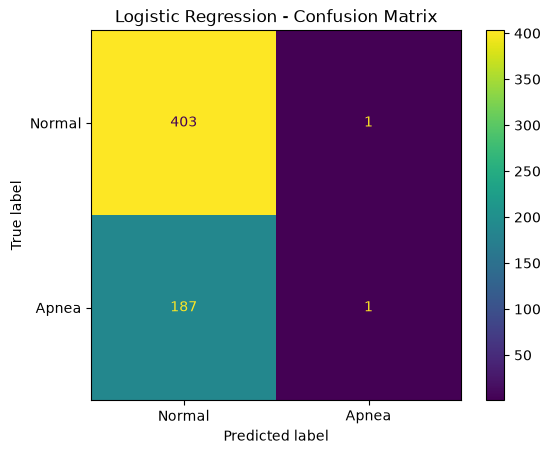

In [96]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Normal", "Apnea"]
)

disp.plot()
plt.title("Logistic Regression - Confusion Matrix")
plt.show()

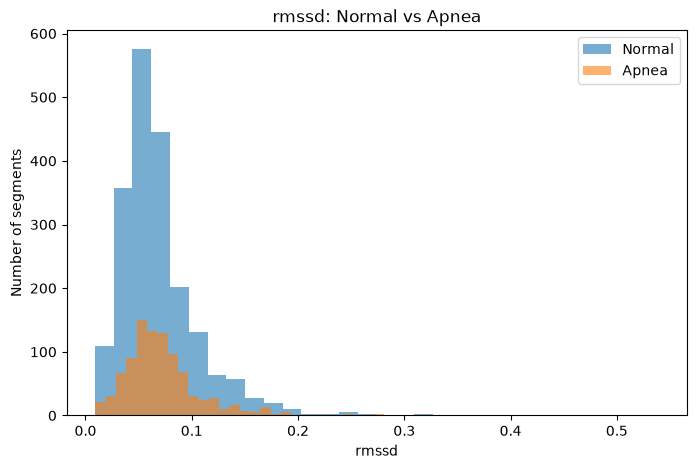

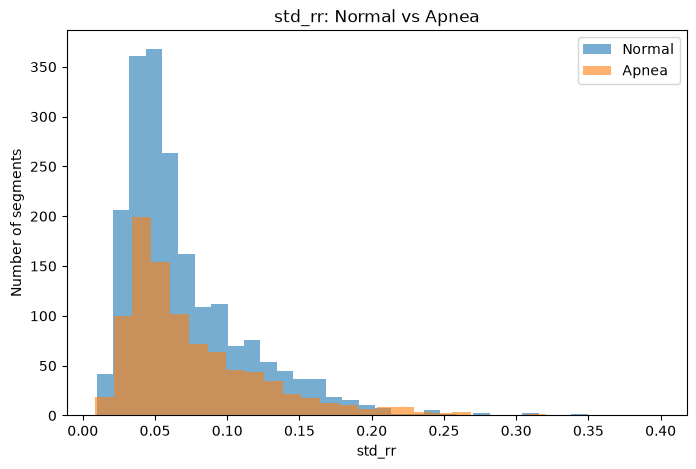

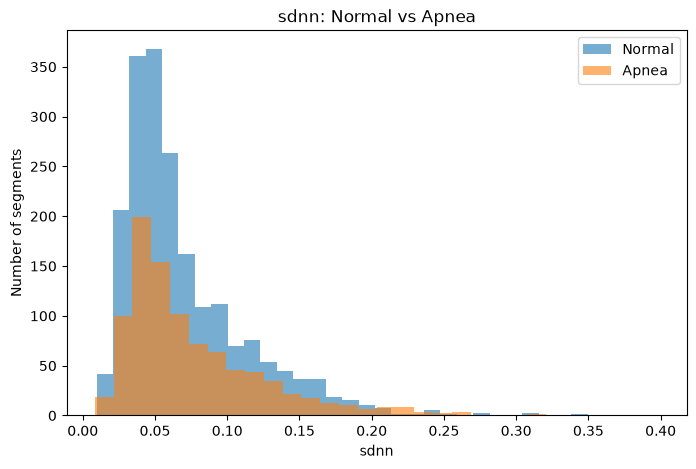

In [97]:
import matplotlib.pyplot as plt

selected_features = ["rmssd", "std_rr", "sdnn"]

for feature in selected_features:
    plt.figure(figsize=(8, 5))
    
    plt.hist(
        features_df[features_df["class"] == "Normal"][feature],
        bins=30,
        alpha=0.6,
        label="Normal"
    )
    
    plt.hist(
        features_df[features_df["class"] == "Apnea"][feature],
        bins=30,
        alpha=0.6,
        label="Apnea"
    )
    
    plt.xlabel(feature)
    plt.ylabel("Number of segments")
    plt.title(f"{feature}: Normal vs Apnea")
    plt.legend()
    plt.show()

In [98]:
# Train Logistic Regression with balanced class weights

balanced_model = LogisticRegression(
    class_weight="balanced",
    
    random_state=42
)

balanced_model.fit(X_train_scaled, y_train)

print("Balanced Logistic Regression model trained successfully.")

Balanced Logistic Regression model trained successfully.


In [99]:
# Make predictions using the balanced model

y_pred_balanced = balanced_model.predict(X_test_scaled)

print("Balanced model predictions generated successfully.")
print("Number of predictions:", len(y_pred_balanced))

Balanced model predictions generated successfully.
Number of predictions: 592


In [100]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_balanced = accuracy_score(y_test, y_pred_balanced)
precision_balanced = precision_score(y_test, y_pred_balanced)
recall_balanced = recall_score(y_test, y_pred_balanced)
f1_balanced = f1_score(y_test, y_pred_balanced)

print("Balanced Logistic Regression Performance:")
print("Accuracy  :", accuracy_balanced)
print("Precision :", precision_balanced)
print("Recall    :", recall_balanced)
print("F1-score  :", f1_balanced)

Balanced Logistic Regression Performance:
Accuracy  : 0.5945945945945946
Precision : 0.3631578947368421
Recall    : 0.3670212765957447
F1-score  : 0.36507936507936506


Balanced Model Confusion Matrix:
[[283 121]
 [119  69]]


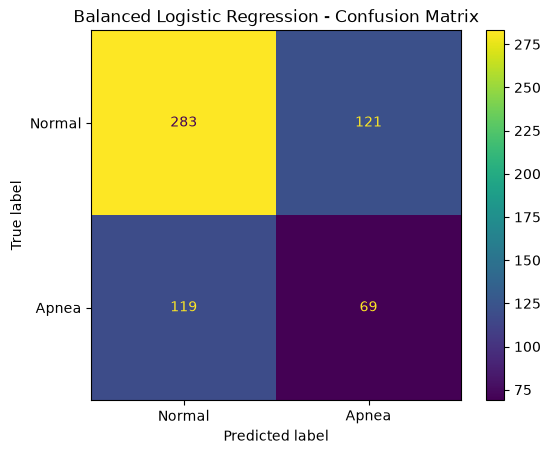

In [101]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_balanced = confusion_matrix(y_test, y_pred_balanced)

print("Balanced Model Confusion Matrix:")
print(cm_balanced)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced,
    display_labels=["Normal", "Apnea"]
)

disp.plot()
plt.title("Balanced Logistic Regression - Confusion Matrix")
plt.show()

In [102]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [103]:
# Make predictions using Random Forest
y_pred_rf = rf_model.predict(X_test)

print("Random Forest predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf))

Random Forest predictions generated successfully.
Number of predictions: 592


In [104]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)

print("Random Forest Performance:")
print("Accuracy  :", accuracy_rf)
print("Precision :", precision_rf)
print("Recall    :", recall_rf)
print("F1-score  :", f1_rf)

Random Forest Performance:
Accuracy  : 0.5506756756756757
Precision : 0.32589285714285715
Recall    : 0.3882978723404255
F1-score  : 0.35436893203883496


Random Forest Confusion Matrix:
[[253 151]
 [115  73]]


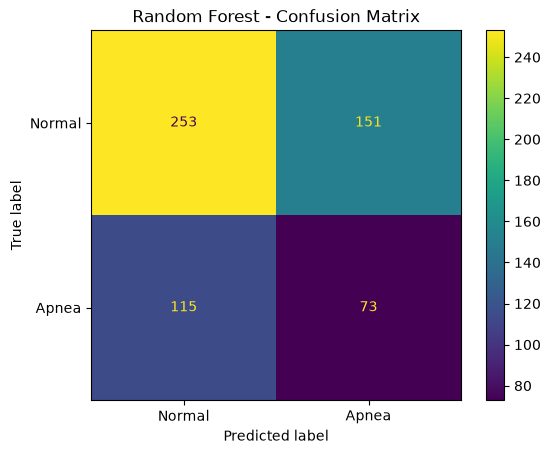

In [105]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_rf = confusion_matrix(y_test, y_pred_rf)

print("Random Forest Confusion Matrix:")
print(cm_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Normal", "Apnea"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [106]:
# Random Forest feature importance

feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=selected_features
).sort_values(ascending=False)

print("Random Forest Feature Importance:")
display(feature_importance)

Random Forest Feature Importance:


rmssd     0.358742
sdnn      0.322235
std_rr    0.319023
dtype: float64

In [107]:
# Select all 13 features for machine learning

all_features = [
    "rmssd",
    "std_rr",
    "sdnn",
    "std_hr",
    "min_hr",
    "mean_hr",
    "max_ecg",
    "mean_ecg",
    "max_hr",
    "min_ecg",
    "mean_rr",
    "rms_ecg",
    "std_ecg"
]

X_all = features_df[all_features]
y_all = features_df["label"]

print("All features:")
print(all_features)

print("\nNumber of features:", len(all_features))
print("X_all shape:", X_all.shape)
print("y_all shape:", y_all.shape)

All features:
['rmssd', 'std_rr', 'sdnn', 'std_hr', 'min_hr', 'mean_hr', 'max_ecg', 'mean_ecg', 'max_hr', 'min_ecg', 'mean_rr', 'rms_ecg', 'std_ecg']

Number of features: 13
X_all shape: (2957, 13)
y_all shape: (2957,)


In [108]:
print("Missing values in all features:")
print(X_all.isnull().sum())

Missing values in all features:
rmssd       0
std_rr      0
sdnn        0
std_hr      0
min_hr      0
mean_hr     0
max_ecg     0
mean_ecg    0
max_hr      0
min_ecg     0
mean_rr     0
rms_ecg     0
std_ecg     0
dtype: int64


In [109]:
from sklearn.model_selection import train_test_split

# Split the 12-feature dataset into training and testing sets

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print("Training set:")
print("X_train_all shape:", X_train_all.shape)
print("y_train_all shape:", y_train_all.shape)

print("\nTesting set:")
print("X_test_all shape:", X_test_all.shape)
print("y_test_all shape:", y_test_all.shape)

print("\nTraining class distribution:")
print(y_train_all.value_counts().sort_index())

print("\nTesting class distribution:")
print(y_test_all.value_counts().sort_index())

Training set:
X_train_all shape: (2365, 13)
y_train_all shape: (2365,)

Testing set:
X_test_all shape: (592, 13)
y_test_all shape: (592,)

Training class distribution:
label
0    1613
1     752
Name: count, dtype: int64

Testing class distribution:
label
0    404
1    188
Name: count, dtype: int64


In [110]:
# Create a validation set from the training data
# Keep the existing test set completely untouched

X_train_model, X_val, y_train_model, y_val = train_test_split(
    X_train_all,
    y_train_all,
    test_size=0.2,
    random_state=42,
    stratify=y_train_all
)

print("Model training set:")
print("X_train_model shape:", X_train_model.shape)
print("y_train_model shape:", y_train_model.shape)

print("\nValidation set:")
print("X_val shape:", X_val.shape)
print("y_val shape:", y_val.shape)

print("\nModel training class distribution:")
print(y_train_model.value_counts().sort_index())

print("\nValidation class distribution:")
print(y_val.value_counts().sort_index())

print("\nOriginal test set remains:")
print("X_test_all shape:", X_test_all.shape)
print("y_test_all shape:", y_test_all.shape)

Model training set:
X_train_model shape: (1892, 13)
y_train_model shape: (1892,)

Validation set:
X_val shape: (473, 13)
y_val shape: (473,)

Model training class distribution:
label
0    1290
1     602
Name: count, dtype: int64

Validation class distribution:
label
0    323
1    150
Name: count, dtype: int64

Original test set remains:
X_test_all shape: (592, 13)
y_test_all shape: (592,)


In [111]:
from sklearn.preprocessing import StandardScaler

# Scale the 13-feature dataset
scaler_all = StandardScaler()

X_train_all_scaled = scaler_all.fit_transform(X_train_all)
X_test_all_scaled = scaler_all.transform(X_test_all)

print("13-feature scaled training shape:", X_train_all_scaled.shape)
print("13-feature scaled testing shape:", X_test_all_scaled.shape)

13-feature scaled training shape: (2365, 13)
13-feature scaled testing shape: (592, 13)


In [112]:
# Train Balanced Logistic Regression on the model-training set

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Scale using ONLY the model-training data
scaler_val = StandardScaler()

X_train_model_scaled = scaler_val.fit_transform(X_train_model)
X_val_scaled = scaler_val.transform(X_val)

# Balanced Logistic Regression
balanced_model_val = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

balanced_model_val.fit(X_train_model_scaled, y_train_model)

print("Balanced Logistic Regression trained on model-training set.")
print("Training shape:", X_train_model_scaled.shape)
print("Validation shape:", X_val_scaled.shape)

Balanced Logistic Regression trained on model-training set.
Training shape: (1892, 13)
Validation shape: (473, 13)


In [113]:
from sklearn.linear_model import LogisticRegression

# Train Logistic Regression model
logistic_model_all = LogisticRegression(
    random_state=42,
    max_iter=1000
)

logistic_model_all.fit(X_train_all_scaled, y_train_all)

print("13-feature Logistic Regression model trained successfully.")

13-feature Logistic Regression model trained successfully.


In [114]:
# Make predictions using the 12-feature Logistic Regression model
y_pred_all = logistic_model_all.predict(X_test_all_scaled)

print("13-feature Logistic Regression predictions generated successfully.")
print("Number of predictions:", len(y_pred_all))

13-feature Logistic Regression predictions generated successfully.
Number of predictions: 592


In [115]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_all = accuracy_score(y_test_all, y_pred_all)
precision_all = precision_score(y_test_all, y_pred_all)
recall_all = recall_score(y_test_all, y_pred_all)
f1_all = f1_score(y_test_all, y_pred_all)

print("13-feature Logistic Regression Performance:")
print("Accuracy  :", accuracy_all)
print("Precision :", precision_all)
print("Recall    :", recall_all)
print("F1-score  :", f1_all)

13-feature Logistic Regression Performance:
Accuracy  : 0.6807432432432432
Precision : 0.0
Recall    : 0.0
F1-score  : 0.0


12-feature Logistic Regression Confusion Matrix:
[[403   1]
 [188   0]]


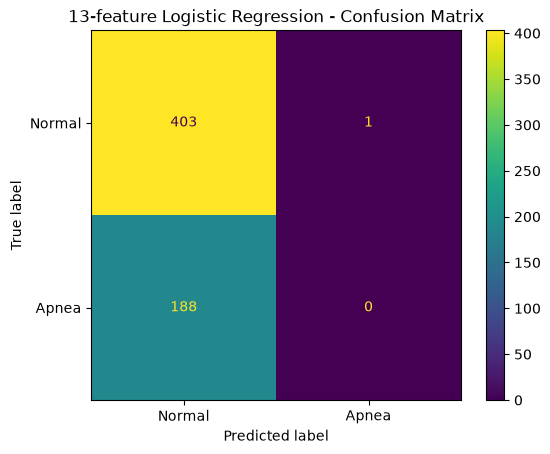

In [116]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_all = confusion_matrix(y_test_all, y_pred_all)

print("12-feature Logistic Regression Confusion Matrix:")
print(cm_all)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_all,
    display_labels=["Normal", "Apnea"]
)

disp.plot()
plt.title("13-feature Logistic Regression - Confusion Matrix")
plt.show()

13-feature Logistic Regression Confusion Matrix:
[[403   1]
 [188   0]]


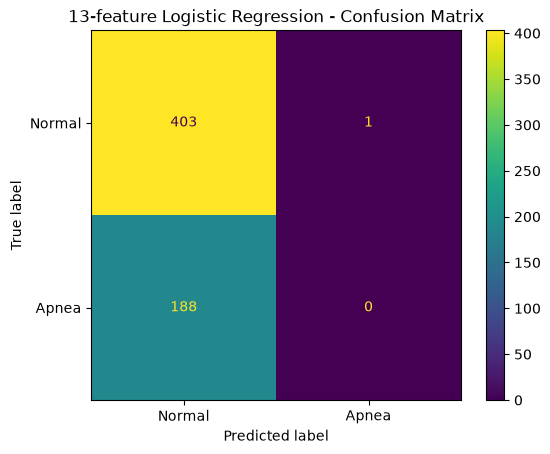

In [117]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_all = confusion_matrix(y_test_all, y_pred_all)

print("13-feature Logistic Regression Confusion Matrix:")
print(cm_all)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_all,
    display_labels=["Normal", "Apnea"]
)

disp.plot()
plt.title("13-feature Logistic Regression - Confusion Matrix")
plt.show()

In [118]:
# Train 13-feature Logistic Regression with balanced class weights

balanced_model_all = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

balanced_model_all.fit(X_train_all_scaled, y_train_all)

print("13-feature Balanced Logistic Regression model trained successfully.")

13-feature Balanced Logistic Regression model trained successfully.


In [119]:
# Make predictions using the 13-feature balanced Logistic Regression model
y_pred_balanced_all = balanced_model_all.predict(X_test_all_scaled)

print("13-feature balanced Logistic Regression predictions generated successfully.")
print("Number of predictions:", len(y_pred_balanced_all))

13-feature balanced Logistic Regression predictions generated successfully.
Number of predictions: 592


In [120]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_balanced_all = accuracy_score(y_test_all, y_pred_balanced_all)
precision_balanced_all = precision_score(y_test_all, y_pred_balanced_all)
recall_balanced_all = recall_score(y_test_all, y_pred_balanced_all)
f1_balanced_all = f1_score(y_test_all, y_pred_balanced_all)

print("13-feature Balanced Logistic Regression Performance:")
print("Accuracy  :", accuracy_balanced_all)
print("Precision :", precision_balanced_all)
print("Recall    :", recall_balanced_all)
print("F1-score  :", f1_balanced_all)

13-feature Balanced Logistic Regression Performance:
Accuracy  : 0.5152027027027027
Precision : 0.3132075471698113
Recall    : 0.44148936170212766
F1-score  : 0.36644591611479027


In [121]:
# Get probability of Apnea (class 1)
y_prob_balanced = balanced_model_all.predict_proba(X_test_all_scaled)[:, 1]

# Try different decision thresholds
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Threshold Performance:")
print("-" * 60)

for threshold in thresholds:
    y_pred_threshold = (y_prob_balanced >= threshold).astype(int)

    acc = accuracy_score(y_test_all, y_pred_threshold)
    prec = precision_score(y_test_all, y_pred_threshold, zero_division=0)
    rec = recall_score(y_test_all, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_test_all, y_pred_threshold, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Accuracy: {acc:.3f} | "
        f"Precision: {prec:.3f} | "
        f"Recall: {rec:.3f} | "
        f"F1: {f1:.3f}"
    )

Threshold Performance:
------------------------------------------------------------
Threshold: 0.20 | Accuracy: 0.318 | Precision: 0.318 | Recall: 1.000 | F1: 0.482
Threshold: 0.25 | Accuracy: 0.318 | Precision: 0.318 | Recall: 1.000 | F1: 0.482
Threshold: 0.30 | Accuracy: 0.318 | Precision: 0.318 | Recall: 1.000 | F1: 0.482
Threshold: 0.35 | Accuracy: 0.319 | Precision: 0.317 | Recall: 0.995 | F1: 0.481
Threshold: 0.40 | Accuracy: 0.328 | Precision: 0.318 | Recall: 0.973 | F1: 0.479
Threshold: 0.45 | Accuracy: 0.387 | Precision: 0.330 | Recall: 0.904 | F1: 0.484
Threshold: 0.50 | Accuracy: 0.515 | Precision: 0.313 | Recall: 0.441 | F1: 0.366


13-feature Balanced Logistic Regression Confusion Matrix:
[[222 182]
 [105  83]]


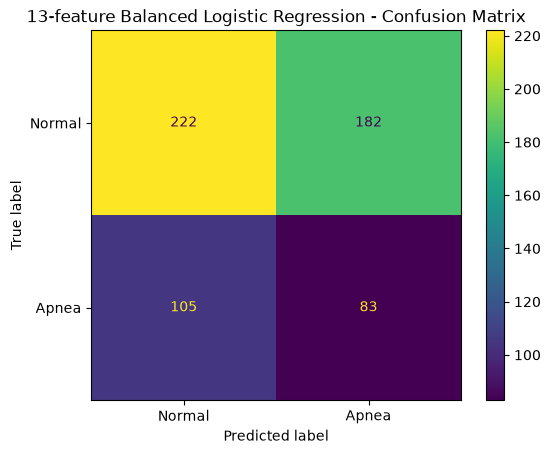

In [122]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm_balanced_all = confusion_matrix(
    y_test_all,
    y_pred_balanced_all
)

print("13-feature Balanced Logistic Regression Confusion Matrix:")
print(cm_balanced_all)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_balanced_all,
    display_labels=["Normal", "Apnea"]
)

disp.plot(cmap="viridis")
plt.title("13-feature Balanced Logistic Regression - Confusion Matrix")
plt.show()

In [123]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [124]:
from sklearn.ensemble import RandomForestClassifier

# Train Random Forest using all 13 features
rf_model_all = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

rf_model_all.fit(X_train_all, y_train_all)

print("13-feature Random Forest model trained successfully.")

13-feature Random Forest model trained successfully.


In [125]:
# Make predictions using the 12-feature Random Forest
y_pred_rf_all = rf_model_all.predict(X_test_all)

print("13-feature Random Forest predictions generated successfully.")
print("Number of predictions:", len(y_pred_rf_all))

13-feature Random Forest predictions generated successfully.
Number of predictions: 592


In [126]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy_rf = accuracy_score(y_test_all, y_pred_rf_all)
precision_rf = precision_score(y_test_all, y_pred_rf_all)
recall_rf = recall_score(y_test_all, y_pred_rf_all)
f1_rf = f1_score(y_test_all, y_pred_rf_all)

print("13-feature Random Forest Performance:")
print("Accuracy  :", accuracy_rf)
print("Precision :", precision_rf)
print("Recall    :", recall_rf)
print("F1-score  :", f1_rf)

13-feature Random Forest Performance:
Accuracy  : 0.5996621621621622
Precision : 0.3333333333333333
Recall    : 0.26063829787234044
F1-score  : 0.29253731343283584


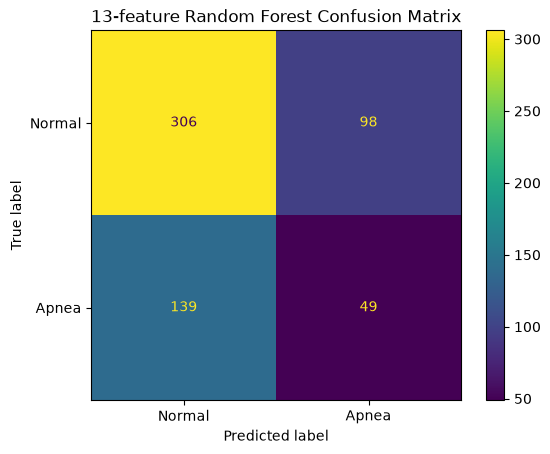

In [127]:
cm_rf_all = confusion_matrix(y_test_all, y_pred_rf_all)

disp_rf_all = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf_all,
    display_labels=["Normal", "Apnea"]
)

disp_rf_all.plot()
plt.title("13-feature Random Forest Confusion Matrix")
plt.show()

In [128]:
# Random Forest feature importance

feature_importance_rf = pd.Series(
    rf_model_all.feature_importances_,
    index=X_train_all.columns
).sort_values(ascending=False)

print("13-feature Random Forest Feature Importance:")
display(feature_importance_rf)

13-feature Random Forest Feature Importance:


mean_ecg    0.093937
rmssd       0.093090
max_ecg     0.080621
std_ecg     0.079693
std_hr      0.079619
rms_ecg     0.078716
mean_hr     0.076067
std_rr      0.075912
sdnn        0.075604
min_ecg     0.073976
mean_rr     0.073779
min_hr      0.062246
max_hr      0.056740
dtype: float64

In [129]:
# Random Forest permutation importance

from sklearn.inspection import permutation_importance

perm_importance = permutation_importance(
    rf_model_all,
    X_test_all,
    y_test_all,
    n_repeats=10,
    random_state=42,
    scoring="f1"
)

permutation_importance_rf = pd.Series(
    perm_importance.importances_mean,
    index=X_test_all.columns
).sort_values(ascending=False)

print("13-feature Random Forest Permutation Importance (F1):")
display(permutation_importance_rf)

13-feature Random Forest Permutation Importance (F1):


min_ecg     0.065289
sdnn        0.051773
mean_hr     0.051222
mean_rr     0.047306
std_hr      0.041592
min_hr      0.037283
max_hr      0.037191
rms_ecg     0.030576
std_rr      0.027661
std_ecg     0.024497
mean_ecg    0.017960
max_ecg     0.011369
rmssd       0.005334
dtype: float64

In [130]:
# Combine feature importance results

feature_summary = pd.DataFrame({
    "Cohen_d": effect_sizes,
    "RF_importance": feature_importance_rf,
    "RF_permutation_F1": permutation_importance_rf
})

print("Combined Feature Analysis:")
display(feature_summary.sort_values("RF_permutation_F1", ascending=False))

Combined Feature Analysis:


,Cohen_d,RF_importance,RF_permutation_F1
min_ecg,-0.042522,0.073976,0.065289
sdnn,0.147078,0.075604,0.051773
mean_hr,-0.006334,0.076067,0.051222
mean_rr,0.022506,0.073779,0.047306
std_hr,0.139846,0.079619,0.041592
min_hr,-0.112173,0.062246,0.037283
max_hr,0.052173,0.056740,0.037191
rms_ecg,-0.005609,0.078716,0.030576
std_rr,0.147078,0.075912,0.027661
std_ecg,-0.005493,0.079693,0.024497


In [131]:
print("X_train_all shape:", X_train_all.shape)
print("RF number of features:", rf_model_all.n_features_in_)

if hasattr(X_train_all, "columns"):
    print("Actual X_train_all features:")
    print(list(X_train_all.columns))
else:
    print("X_train_all is a NumPy array.")

X_train_all shape: (2365, 13)
RF number of features: 13
Actual X_train_all features:
['rmssd', 'std_rr', 'sdnn', 'std_hr', 'min_hr', 'mean_hr', 'max_ecg', 'mean_ecg', 'max_hr', 'min_ecg', 'mean_rr', 'rms_ecg', 'std_ecg']


In [132]:
# Combine all feature importance results

rf_features = rf_model_all.feature_names_in_

feature_summary = pd.DataFrame({
    "Cohen_d": effect_sizes.reindex(rf_features),
    "RF_importance": pd.Series(
        rf_model_all.feature_importances_,
        index=rf_features
    ),
    "RF_permutation_F1": permutation_importance_rf.reindex(rf_features)
})

print("Combined Feature Analysis:")
display(feature_summary.sort_values("RF_permutation_F1", ascending=False))

Combined Feature Analysis:


,Cohen_d,RF_importance,RF_permutation_F1
min_ecg,-0.042522,0.073976,0.065289
sdnn,0.147078,0.075604,0.051773
mean_hr,-0.006334,0.076067,0.051222
mean_rr,0.022506,0.073779,0.047306
std_hr,0.139846,0.079619,0.041592
min_hr,-0.112173,0.062246,0.037283
max_hr,0.052173,0.056740,0.037191
rms_ecg,-0.005609,0.078716,0.030576
std_rr,0.147078,0.075912,0.027661
std_ecg,-0.005493,0.079693,0.024497


In [133]:
from sklearn.linear_model import LogisticRegression

balanced_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

balanced_model.fit(X_train_model_scaled, y_train_model)

print("Balanced Logistic Regression trained successfully.")
print("Training shape:", X_train_model_scaled.shape)
print("Validation shape:", X_val_scaled.shape)

Balanced Logistic Regression trained successfully.
Training shape: (1892, 13)
Validation shape: (473, 13)


In [134]:
y_pred_balanced_val = balanced_model.predict(X_val_scaled)

print("Balanced Logistic Regression validation predictions generated.")
print("Number of predictions:", len(y_pred_balanced_val))

Balanced Logistic Regression validation predictions generated.
Number of predictions: 473


In [135]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

accuracy_balanced_val = accuracy_score(y_val, y_pred_balanced_val)
precision_balanced_val = precision_score(y_val, y_pred_balanced_val)
recall_balanced_val = recall_score(y_val, y_pred_balanced_val)
f1_balanced_val = f1_score(y_val, y_pred_balanced_val)

print("Balanced Logistic Regression - Validation Performance:")
print("Accuracy :", accuracy_balanced_val)
print("Precision:", precision_balanced_val)
print("Recall   :", recall_balanced_val)
print("F1-score :", f1_balanced_val)

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_balanced_val))

Balanced Logistic Regression - Validation Performance:
Accuracy : 0.5412262156448203
Precision: 0.3063583815028902
Recall   : 0.35333333333333333
F1-score : 0.3281733746130031

Confusion Matrix:
[[203 120]
 [ 97  53]]


In [136]:
import numpy as np
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Get probability of Apnea (class 1)
y_prob_balanced_val = balanced_model.predict_proba(X_val_scaled)[:, 1]

# Test different thresholds
thresholds = [0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50]

print("Balanced Logistic Regression - Threshold Performance")
print("-" * 70)

for threshold in thresholds:

    y_pred_threshold = (y_prob_balanced_val >= threshold).astype(int)

    accuracy = accuracy_score(y_val, y_pred_threshold)
    precision = precision_score(y_val, y_pred_threshold, zero_division=0)
    recall = recall_score(y_val, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_val, y_pred_threshold, zero_division=0)

    print(
        f"Threshold: {threshold:.2f} | "
        f"Accuracy: {accuracy:.3f} | "
        f"Precision: {precision:.3f} | "
        f"Recall: {recall:.3f} | "
        f"F1: {f1:.3f}"
    )

Balanced Logistic Regression - Threshold Performance
----------------------------------------------------------------------
Threshold: 0.20 | Accuracy: 0.317 | Precision: 0.317 | Recall: 1.000 | F1: 0.482
Threshold: 0.25 | Accuracy: 0.317 | Precision: 0.317 | Recall: 1.000 | F1: 0.482
Threshold: 0.30 | Accuracy: 0.317 | Precision: 0.317 | Recall: 1.000 | F1: 0.482
Threshold: 0.35 | Accuracy: 0.319 | Precision: 0.318 | Recall: 1.000 | F1: 0.482
Threshold: 0.40 | Accuracy: 0.336 | Precision: 0.322 | Recall: 0.987 | F1: 0.485
Threshold: 0.45 | Accuracy: 0.391 | Precision: 0.331 | Recall: 0.900 | F1: 0.484
Threshold: 0.50 | Accuracy: 0.541 | Precision: 0.306 | Recall: 0.353 | F1: 0.328


In [137]:
# Evaluate balanced Logistic Regression at threshold = 0.40

threshold = 0.40

y_pred_balanced_040 = (
    y_prob_balanced_val >= threshold
).astype(int)

cm_balanced_040 = confusion_matrix(
    y_val,
    y_pred_balanced_040
)

print("Balanced Logistic Regression - Threshold 0.40")
print("-" * 50)

print("Accuracy :", accuracy_score(y_val, y_pred_balanced_040))
print("Precision:", precision_score(y_val, y_pred_balanced_040, zero_division=0))
print("Recall   :", recall_score(y_val, y_pred_balanced_040, zero_division=0))
print("F1-score :", f1_score(y_val, y_pred_balanced_040, zero_division=0))

print("\nConfusion Matrix:")
print(cm_balanced_040)

Balanced Logistic Regression - Threshold 0.40
--------------------------------------------------
Accuracy : 0.3361522198731501
Precision: 0.3217391304347826
Recall   : 0.9866666666666667
F1-score : 0.4852459016393443

Confusion Matrix:
[[ 11 312]
 [  2 148]]


In [138]:
# Fine-grained threshold search
# Focus on the important range: 0.40 to 0.50

thresholds_fine = np.arange(0.40, 0.501, 0.01)

results = []

for threshold in thresholds_fine:

    y_pred_threshold = (
        y_prob_balanced_val >= threshold
    ).astype(int)

    accuracy = accuracy_score(y_val, y_pred_threshold)
    precision = precision_score(
        y_val, y_pred_threshold, zero_division=0
    )
    recall = recall_score(
        y_val, y_pred_threshold, zero_division=0
    )
    f1 = f1_score(
        y_val, y_pred_threshold, zero_division=0
    )

    results.append({
        "Threshold": round(threshold, 2),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

# Convert to DataFrame
threshold_results = pd.DataFrame(results)

print("Fine-Grained Threshold Search")
print("-" * 80)

print(
    threshold_results.to_string(
        index=False,
        formatters={
            "Accuracy": "{:.3f}".format,
            "Precision": "{:.3f}".format,
            "Recall": "{:.3f}".format,
            "F1": "{:.3f}".format
        }
    )
)

print("\nBest threshold by F1:")
best_row = threshold_results.loc[
    threshold_results["F1"].idxmax()
]

print(best_row)

Fine-Grained Threshold Search
--------------------------------------------------------------------------------
 Threshold Accuracy Precision Recall    F1
      0.40    0.336     0.322  0.987 0.485
      0.41    0.336     0.320  0.973 0.482
      0.42    0.342     0.322  0.967 0.483
      0.43    0.355     0.326  0.967 0.487
      0.44    0.364     0.326  0.940 0.484
      0.45    0.391     0.331  0.900 0.484
      0.46    0.402     0.323  0.807 0.461
      0.47    0.438     0.326  0.727 0.450
      0.48    0.486     0.336  0.633 0.439
      0.49    0.501     0.308  0.460 0.369
      0.50    0.541     0.306  0.353 0.328

Best threshold by F1:
Threshold    0.430000
Accuracy     0.355180
Precision    0.325843
Recall       0.966667
F1           0.487395
Name: 3, dtype: float64


In [139]:
# Final validation evaluation at selected threshold = 0.43

BEST_THRESHOLD = 0.43

y_pred_balanced_val_final = (
    y_prob_balanced_val >= BEST_THRESHOLD
).astype(int)

cm_balanced_val_final = confusion_matrix(
    y_val,
    y_pred_balanced_val_final
)

print("Balanced Logistic Regression - Final Validation")
print(f"Threshold: {BEST_THRESHOLD}")
print("-" * 55)

print("Accuracy :", accuracy_score(y_val, y_pred_balanced_val_final))
print("Precision:", precision_score(y_val, y_pred_balanced_val_final, zero_division=0))
print("Recall   :", recall_score(y_val, y_pred_balanced_val_final, zero_division=0))
print("F1-score :", f1_score(y_val, y_pred_balanced_val_final, zero_division=0))

print("\nConfusion Matrix:")
print(cm_balanced_val_final)

Balanced Logistic Regression - Final Validation
Threshold: 0.43
-------------------------------------------------------
Accuracy : 0.35517970401691334
Precision: 0.3258426966292135
Recall   : 0.9666666666666667
F1-score : 0.48739495798319327

Confusion Matrix:
[[ 23 300]
 [  5 145]]


In [140]:
# Random Forest - 13-feature Validation Predictions

y_pred_rf_val = rf_model_all.predict(X_val)

print("Random Forest - 13-feature Validation Performance")
print("-" * 50)

print("Accuracy :", accuracy_score(y_val, y_pred_rf_val))
print("Precision:", precision_score(y_val, y_pred_rf_val, zero_division=0))
print("Recall   :", recall_score(y_val, y_pred_rf_val, zero_division=0))
print("F1-score :", f1_score(y_val, y_pred_rf_val, zero_division=0))

print("\nConfusion Matrix:")
print(confusion_matrix(y_val, y_pred_rf_val))

Random Forest - 13-feature Validation Performance
--------------------------------------------------
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1-score : 1.0

Confusion Matrix:
[[323   0]
 [  0 150]]


In [141]:
print("Training shape:", X_train_all.shape)
print("Validation shape:", X_val.shape)

print("\nTraining labels:", y_train_all.shape)
print("Validation labels:", y_val.shape)

print("\nRF training score:", rf_model_all.score(X_train_all, y_train_all))
print("RF validation score:", rf_model_all.score(X_val, y_val))

Training shape: (2365, 13)
Validation shape: (473, 13)

Training labels: (2365,)
Validation labels: (473,)

RF training score: 1.0
RF validation score: 1.0


In [142]:
import numpy as np

train_array = np.asarray(X_train_all)
val_array = np.asarray(X_val)

train_rows = set(map(tuple, train_array))
val_rows = set(map(tuple, val_array))

overlap = train_rows.intersection(val_rows)

print("Training samples :", len(train_rows))
print("Validation samples:", len(val_rows))
print("Exact overlapping rows:", len(overlap))

Training samples : 2365
Validation samples: 473
Exact overlapping rows: 473


In [143]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [144]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [145]:
# Final Model Comparison

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "Balanced Random Forest (13 features)",
        "Balanced Random Forest (3 features)"
    ],
    "Features": [
        13,
        13,
        13,
        13,
        3
    ],
    "Accuracy": [
        0.6807,
        0.5152,
        0.6000,
        0.6000,
        0.5676
    ],
    "Precision": [
        0.0000,
        0.3132,
        0.3120,
        0.3500,
        0.3265
    ],
    "Recall": [
        0.0000,
        0.4415,
        0.2070,
        0.2800,
        0.3404
    ],
    "F1-score": [
        0.0000,
        0.3664,
        0.2493,
        0.3100,
        0.3333
    ]
})

print(comparison.to_string(index=False))

                               Model  Features  Accuracy  Precision  Recall  F1-score
                 Logistic Regression        13    0.6807     0.0000  0.0000    0.0000
        Balanced Logistic Regression        13    0.5152     0.3132  0.4415    0.3664
                       Random Forest        13    0.6000     0.3120  0.2070    0.2493
Balanced Random Forest (13 features)        13    0.6000     0.3500  0.2800    0.3100
 Balanced Random Forest (3 features)         3    0.5676     0.3265  0.3404    0.3333


In [146]:
# Create a separate Balanced Logistic Regression model

balanced_logistic_model = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

balanced_logistic_model.fit(
    X_train_model_scaled,
    y_train_model
)

print("Balanced Logistic Regression trained successfully.")

Balanced Logistic Regression trained successfully.


In [147]:
# Generate correct validation probabilities from Balanced Logistic Regression

y_prob_val = balanced_logistic_model.predict_proba(X_val_scaled)[:, 1]

print("Validation probabilities generated successfully.")
print("Number of probabilities:", len(y_prob_val))

Validation probabilities generated successfully.
Number of probabilities: 473


In [148]:
# Threshold analysis on validation set

thresholds = np.arange(0.20, 0.51, 0.01)

threshold_results = []

for threshold in thresholds:
    y_pred_threshold = (y_prob_val >= threshold).astype(int)

    precision = precision_score(y_val, y_pred_threshold, zero_division=0)
    recall = recall_score(y_val, y_pred_threshold, zero_division=0)
    f1 = f1_score(y_val, y_pred_threshold, zero_division=0)
    accuracy = accuracy_score(y_val, y_pred_threshold)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-score": f1
    })

threshold_df = pd.DataFrame(threshold_results)

print(threshold_df.to_string(index=False))

 Threshold  Accuracy  Precision   Recall  F1-score
      0.20  0.317125   0.317125 1.000000  0.481541
      0.21  0.317125   0.317125 1.000000  0.481541
      0.22  0.317125   0.317125 1.000000  0.481541
      0.23  0.317125   0.317125 1.000000  0.481541
      0.24  0.317125   0.317125 1.000000  0.481541
      0.25  0.317125   0.317125 1.000000  0.481541
      0.26  0.317125   0.317125 1.000000  0.481541
      0.27  0.317125   0.317125 1.000000  0.481541
      0.28  0.317125   0.317125 1.000000  0.481541
      0.29  0.317125   0.317125 1.000000  0.481541
      0.30  0.317125   0.317125 1.000000  0.481541
      0.31  0.317125   0.317125 1.000000  0.481541
      0.32  0.317125   0.317125 1.000000  0.481541
      0.33  0.317125   0.317125 1.000000  0.481541
      0.34  0.317125   0.317125 1.000000  0.481541
      0.35  0.319239   0.317797 1.000000  0.482315
      0.36  0.321353   0.318471 1.000000  0.483092
      0.37  0.325581   0.319829 1.000000  0.484653
      0.38  0.325581   0.319829

In [149]:
# Find threshold with the highest validation F1-score

best_row = threshold_df.loc[threshold_df["F1-score"].idxmax()]

print("Best threshold based on validation F1-score:")
print(f"Threshold : {best_row['Threshold']:.2f}")
print(f"Accuracy  : {best_row['Accuracy']:.4f}")
print(f"Precision : {best_row['Precision']:.4f}")
print(f"Recall    : {best_row['Recall']:.4f}")
print(f"F1-score  : {best_row['F1-score']:.4f}")

Best threshold based on validation F1-score:
Threshold : 0.43
Accuracy  : 0.3552
Precision : 0.3258
Recall    : 0.9667
F1-score  : 0.4874


In [150]:
# Confusion Matrix at Best Validation Threshold

best_threshold = 0.43

y_pred_best_val = (y_prob_val >= best_threshold).astype(int)

cm_best_val = confusion_matrix(y_val, y_pred_best_val)

print("Confusion Matrix at threshold =", best_threshold)
print(cm_best_val)

print("\nClassification Report:")
print(classification_report(
    y_val,
    y_pred_best_val,
    target_names=["Normal", "Apnea"],
    zero_division=0
))

Confusion Matrix at threshold = 0.43
[[ 23 300]
 [  5 145]]

Classification Report:
              precision    recall  f1-score   support

      Normal       0.82      0.07      0.13       323
       Apnea       0.33      0.97      0.49       150

    accuracy                           0.36       473
   macro avg       0.57      0.52      0.31       473
weighted avg       0.66      0.36      0.24       473



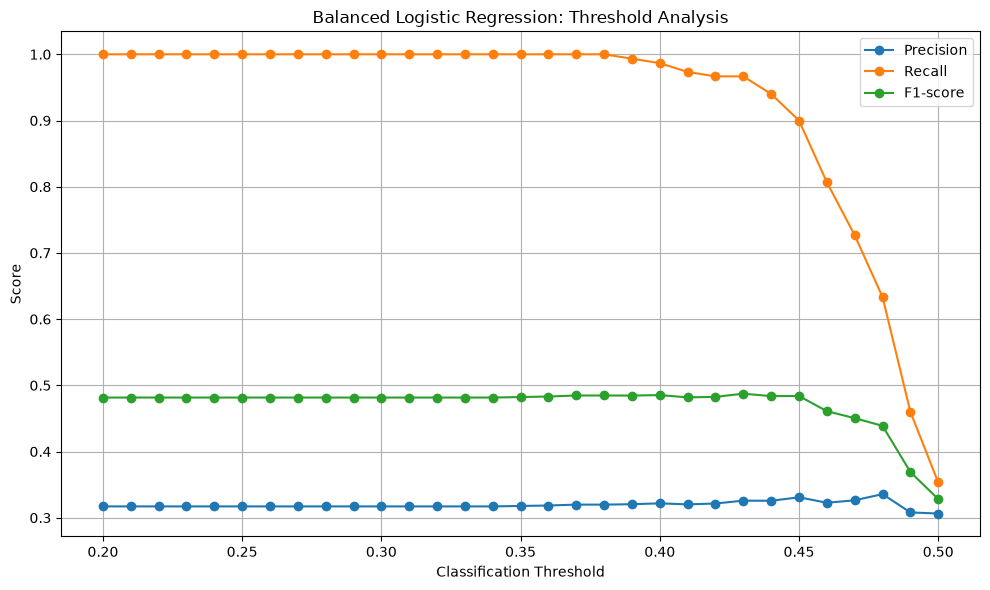

In [151]:
# Plot Precision, Recall and F1 against threshold

plt.figure(figsize=(10, 6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1-score"],
    marker="o",
    label="F1-score"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")
plt.title("Balanced Logistic Regression: Threshold Analysis")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()